# Customer Churn Prediction & LTV Engine

## Final Analytics & Customer Retention Report

**Prepared by:** Akshay

This notebook presents the complete customer churn prediction and lifetime value analysis developed as part of the Customer Churn Prediction & LTV Engine project.

The analysis combines exploratory data analysis, machine learning-based churn prediction, customer lifetime value estimation, customer segmentation, retention prioritization, and business recommendations.

### Objectives

- Analyze customer churn behavior
- Identify factors associated with customer churn
- Develop and compare churn prediction models
- Estimate customer lifetime value (LTV)
- Segment customers based on churn risk and value
- Prioritize customers for retention
- Translate analytical results into actionable business recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("WA_Fn-UseC_-Telco-Customer-Churn (1).csv.xlsx")

## Data Preparation — TotalCharges

The TotalCharges column was initially stored as an object/string data type.
It was converted to numeric using pd.to_numeric() with errors="coerce".
The 11 resulting missing values correspond to customers with zero tenure,
so they were replaced with 0.

In [3]:
# Convert TotalCharges from object/string to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Handle missing TotalCharges values
# Customers with zero tenure have no accumulated total charges
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [4]:
print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Missing TotalCharges values:", df["TotalCharges"].isna().sum())

TotalCharges data type: float64
Missing TotalCharges values: 0


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df["TotalCharges"].dtype

dtype('float64')

## TotalCharges Data Type Correction

The TotalCharges column was initially stored as an object/string data type.
It was converted to numeric using pd.to_numeric() with errors="coerce".
The 11 resulting missing values correspond to customers with zero tenure,
so they were replaced with 0.

In [7]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [8]:
df["TotalCharges"].dtype

dtype('float64')

In [9]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [10]:
df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn


In [11]:
# Handle missing TotalCharges values
# Customers with zero tenure have no accumulated total charges
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [12]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [13]:
df["TotalCharges"].dtype

dtype('float64')

In [14]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [15]:
df.shape

(7043, 21)

In [16]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [18]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
df[["tenure", "MonthlyCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [20]:
# Baseline Customer KPIs

total_customers = df.shape[0]
churned_customers = (df["Churn"] == "Yes").sum()
churn_rate = (churned_customers / total_customers) * 100
average_tenure = df["tenure"].mean()
average_monthly_charges = df["MonthlyCharges"].mean()

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Average Tenure:", round(average_tenure, 2), "months")
print("Average Monthly Charges:", round(average_monthly_charges, 2))

Total Customers: 7043
Churned Customers: 1869
Churn Rate: 26.54 %
Average Tenure: 32.37 months
Average Monthly Charges: 64.76


## 1. Baseline Customer KPIs

The following metrics provide an initial overview of the customer
base and the current churn situation.

In [21]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Churn Rate (%)",
        "Average Tenure (Months)",
        "Average Monthly Charges"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(churn_rate, 2),
        round(average_tenure, 2),
        round(average_monthly_charges, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Churn Rate (%),26.54
3,Average Tenure (Months),32.37
4,Average Monthly Charges,64.76


### Key Findings

- The dataset contains 7,043 customers.
- 1,869 customers have churned.
- The overall churn rate is 26.54%.
- Average customer tenure is 32.37 months.
- Average monthly charge is 64.76.

## 2. Customer Churn Distribution

This chart compares customers who stayed with the company against
customers who churned.

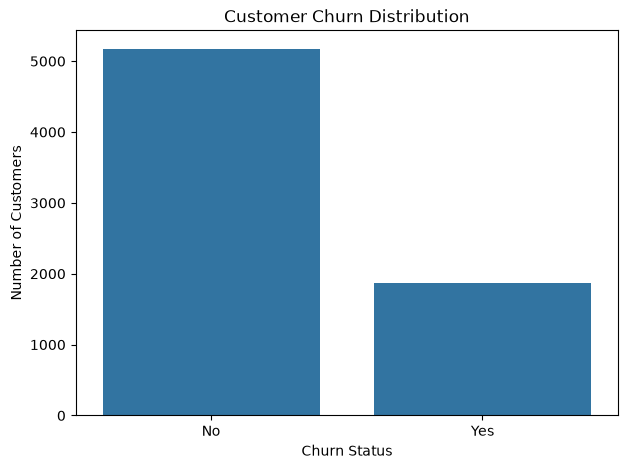

In [22]:
# Churn Distribution

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=churn_counts.index, y=churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

### Finding

The dataset contains 5,174 customers who did not churn and
1,869 customers who churned. The overall churn rate is 26.54%.

## 3. Churn Rate by Contract Type

This analysis compares the percentage of customers who churn
across different contract types.

In [23]:
# Churn by Contract Type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Finding

Month-to-month contract customers have the highest churn rate,
while two-year contract customers have the lowest churn rate.

This indicates that contract type is strongly associated with
customer churn in this dataset.

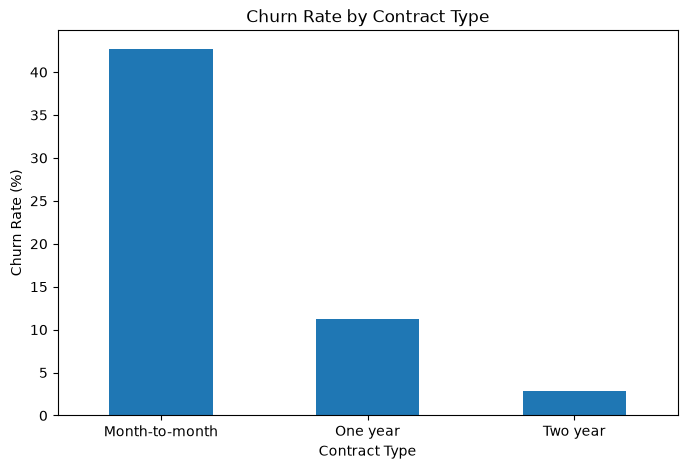

In [24]:
# Visualize churn rate by contract type

contract_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 4. Dashboard Recommendations

Based on the baseline analysis, the following elements are recommended
for the final customer churn dashboard.

### KPI Cards

- Total Customers
- Churned Customers
- Churn Rate
- Average Tenure
- Average Monthly Charges

### Recommended Charts

1. Customer Churn Distribution
2. Churn Rate by Contract Type
3. Churn Rate by Internet Service
4. Churn Rate by Payment Method
5. Churn Rate by Tenure

### Dashboard Purpose

The dashboard should provide a simple overview of the customer base,
highlight the current churn situation, and help stakeholders identify
customer segments that may require further investigation.

The final dashboard design and additional charts should be confirmed
with the team before implementation.

## 5. Conclusion

The baseline analysis provides an initial understanding of the
customer population and churn situation.

The dataset contains 7,043 customers, of which 1,869 have churned,
resulting in an overall churn rate of 26.54%.

The average customer tenure is 32.37 months and the average monthly
charge is 64.76.

The initial visual analysis also shows a clear difference in churn
rates across contract types, with month-to-month customers showing
the highest churn rate.

These results provide the baseline information required for the
next stages of the Customer Churn Prediction & LTV Engine project.

# Customer Churn Dashboard Draft — Day 2

## Dashboard Overview

This section presents the initial dashboard draft based on the
baseline customer churn analysis completed on Day 1.

The dashboard is designed to provide a quick overview of customer
volume, churn status, customer tenure, and monthly charges.

## 1. Key Performance Indicators (KPIs)

The following KPIs provide a quick summary of the customer base and
the current churn situation.

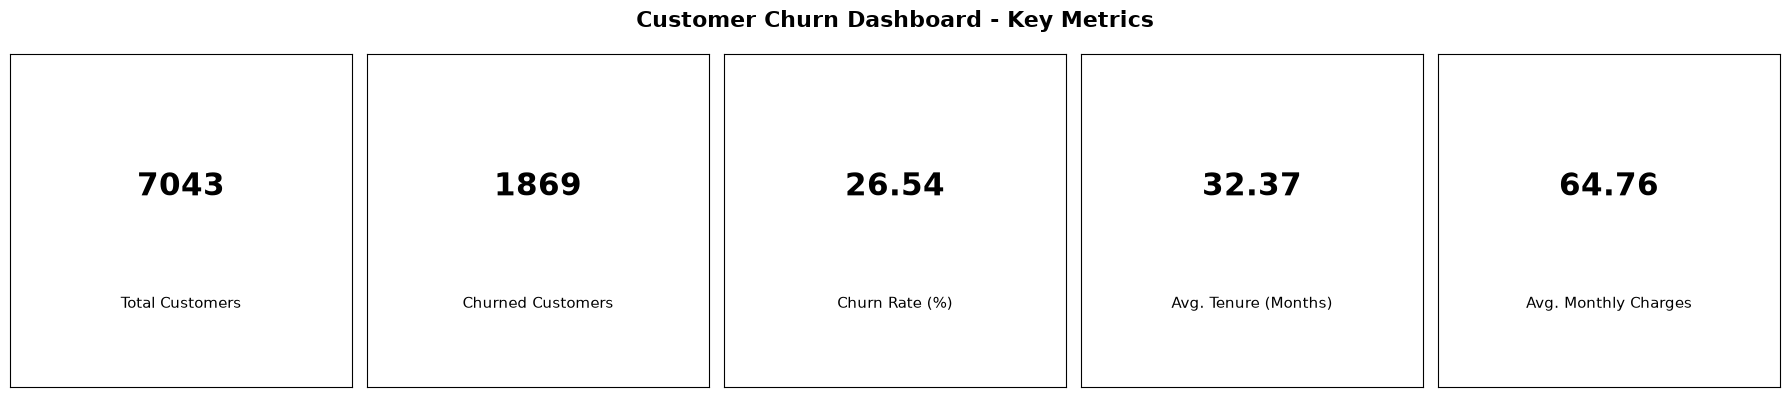

In [25]:
# Day 2 - Dashboard KPI Cards

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

kpis = [
    ("Total Customers", total_customers),
    ("Churned Customers", churned_customers),
    ("Churn Rate (%)", round(churn_rate, 2)),
    ("Avg. Tenure (Months)", round(average_tenure, 2)),
    ("Avg. Monthly Charges", round(average_monthly_charges, 2))
]

for ax, (title, value) in zip(axes, kpis):
    ax.text(
        0.5, 0.6, str(value),
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )
    
    ax.text(
        0.5, 0.25, title,
        ha="center",
        va="center",
        fontsize=11
    )
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.suptitle("Customer Churn Dashboard - Key Metrics",
             fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### KPI Summary

The customer base contains 7,043 customers, with 1,869 customers
having churned. The overall churn rate is 26.54%.

The average customer tenure is 32.37 months, while the average
monthly charge is 64.76.

These KPIs provide a high-level view of the customer base and will
serve as the primary summary metrics for the final dashboard.

## 2. Customer Churn Distribution

This chart shows the number of customers who have churned compared
with customers who have remained with the company.

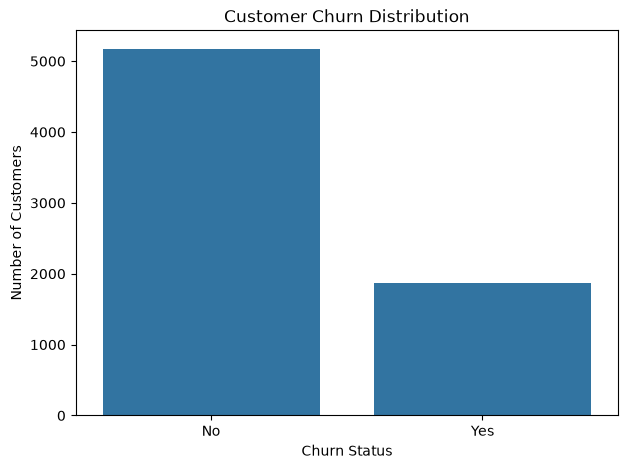

In [26]:
# Dashboard Chart 1 - Customer Churn Distribution

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

### Finding

The dataset contains more customers who stayed with the company than
customers who churned. However, 1,869 customers have churned,
representing an overall churn rate of 26.54%.

This chart provides a simple overview of the current customer churn
situation.

## 3. Churn Rate by Contract Type

This chart compares the percentage of customers who churn across
different contract types.

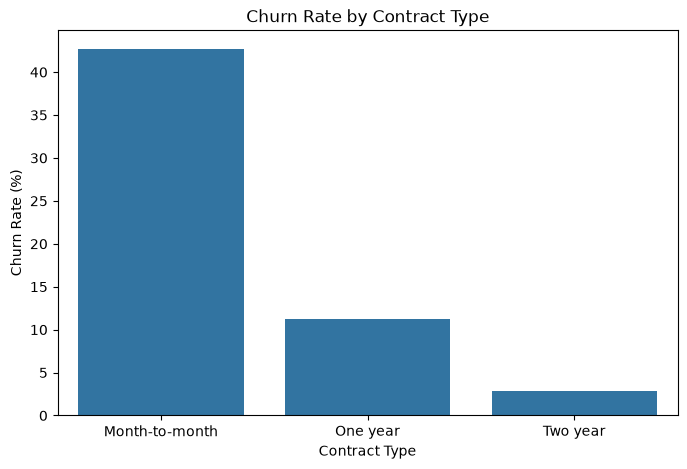

In [27]:
# Dashboard Chart 2 - Churn Rate by Contract Type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn["Yes"]
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

### Finding

Month-to-month contract customers have the highest churn rate,
while two-year contract customers have the lowest churn rate.

This indicates a clear difference in churn rates across contract
types and makes contract type an important segment to consider
in the final dashboard.

## 4. Dashboard Components

Based on the baseline analysis, the initial dashboard should contain
the following components:

### KPI Cards

- Total Customers
- Churned Customers
- Churn Rate
- Average Tenure
- Average Monthly Charges

### Main Charts

- Customer Churn Distribution
- Churn Rate by Contract Type

### Future Dashboard Charts

The following charts can be added after the detailed customer and
service-level analysis is completed:

- Churn Rate by Internet Service
- Churn Rate by Payment Method
- Churn Rate by Tenure

The final dashboard should be updated using the cleaned and
team-approved dataset.

## 5. Proposed Dashboard Layout

The proposed dashboard layout is organized to provide a quick and
clear view of customer churn.

### Top Section — KPI Cards

- Total Customers
- Churned Customers
- Churn Rate
- Average Tenure
- Average Monthly Charges

### Middle Section — Churn Analysis

- Customer Churn Distribution
- Churn Rate by Contract Type

### Lower Section — Detailed Analysis

- Churn Rate by Internet Service
- Churn Rate by Payment Method
- Churn Rate by Tenure

### Dashboard Objective

The dashboard is intended to help stakeholders quickly understand
the overall churn situation and identify customer segments that may
require further investigation.

The final dashboard will be updated after the cleaned and
team-approved dataset is available.

## 6. Day 2 Conclusion

The initial customer churn dashboard draft has been prepared using
the baseline analysis from Day 1.

The dashboard currently includes key customer KPIs, customer churn
distribution, and churn rate by contract type.

Additional charts will be incorporated after the detailed customer
and service-level analysis is completed and the cleaned dataset is
approved by the team.

In [28]:
df["TotalCharges"].dtype

dtype('float64')

In [29]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].dtype

dtype('float64')

In [30]:
df["TotalCharges"].isna().sum()

np.int64(0)

# Day 3 — Detailed Data Cleaning & Exploratory Data Analysis (EDA)

## Objective

The objective of Day 3 is to examine the quality and structure of the
customer churn dataset and identify important customer and service
characteristics associated with customer churn.

The analysis will include data quality checks, numerical and
categorical variable analysis, and churn analysis across important
customer segments.

## 1. Data Quality Check

Before performing detailed exploratory analysis, the dataset is
checked for its dimensions, columns, data types, missing values,
and duplicate records.

In [31]:
# Check number of rows and columns
df.shape

(7043, 21)

In [32]:
# Display all column names
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [33]:
# Check data types of all columns
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [34]:
# Check missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [35]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

## 2. Numerical Variable Analysis

The numerical variables are analyzed using descriptive statistics to understand their central tendency, spread, and range.

In [36]:
# Descriptive statistics for numerical variables
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


### 2.1 Customer Tenure Distribution

The distribution of customer tenure is visualized to understand how long customers have been associated with the company.

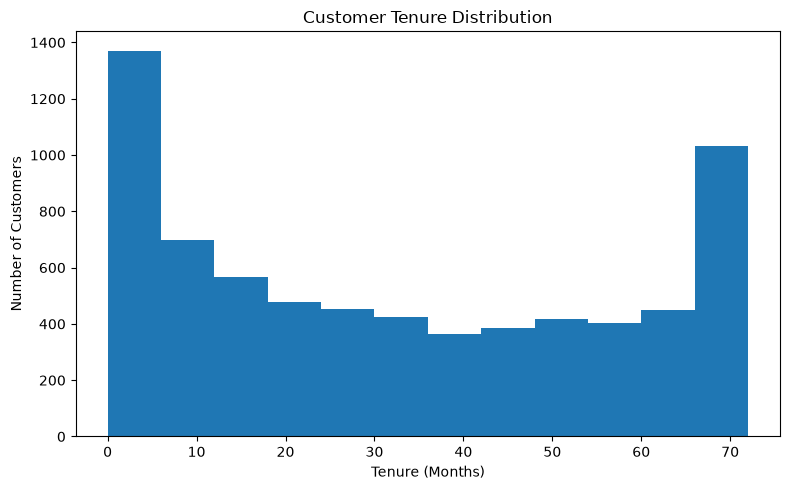

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["tenure"], bins=12)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Finding

The tenure distribution shows a high concentration of customers with very low tenure, particularly during the first few months. A second noticeable concentration is observed among customers with longer tenure near 60–72 months. This indicates that the customer base contains both newer and long-term customers, making tenure an important variable for further churn analysis.

### 2.2 Monthly Charges Distribution

The distribution of monthly charges is visualized to understand the range and concentration of customer monthly billing.

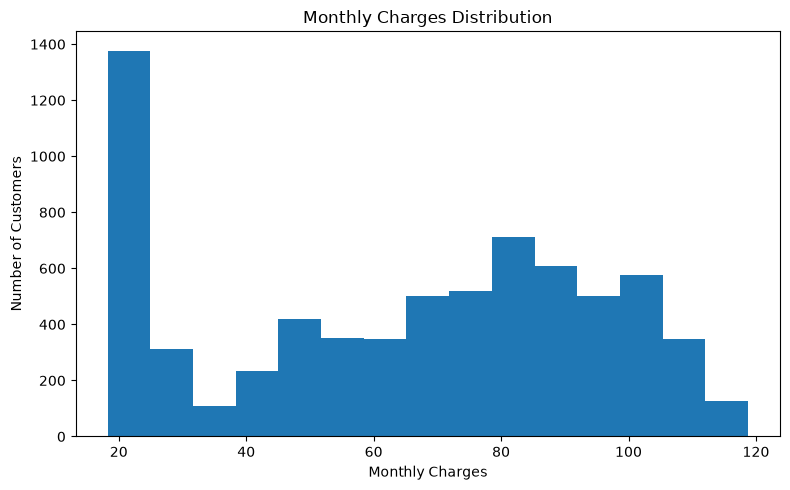

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(df["MonthlyCharges"], bins=15)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Finding

The monthly charges distribution shows a high concentration of customers in the lower monthly-charge range, particularly around 18–30. Customer counts are more distributed across the higher charge ranges, with noticeable concentrations around 70–105. This variation in monthly charges makes it an important variable for further customer churn analysis.

### 2.3 Total Charges Distribution

The distribution of total charges is visualized to understand the accumulated charges paid by customers and identify the overall spread of customer spending.

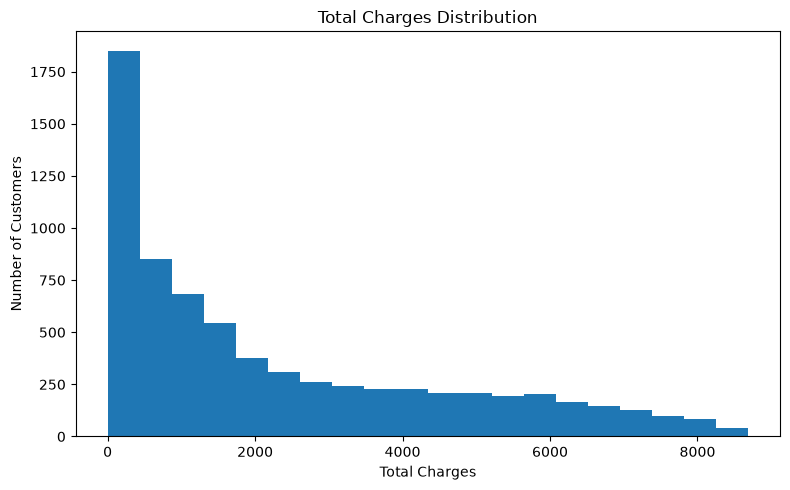

In [39]:
plt.figure(figsize=(8, 5))

plt.hist(df["TotalCharges"], bins=20)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Finding

The TotalCharges distribution is strongly concentrated toward lower total charge values, with the number of customers gradually decreasing as total charges increase. A smaller proportion of customers have high accumulated charges. This pattern is influenced by customer tenure because customers who have stayed longer with the company generally have more accumulated charges.

## 3. Categorical Variable Analysis

Categorical variables are analyzed to understand the distribution of customers across different groups and identify segments that may show differences in churn behavior.

In [40]:
# Check the number of customers in each contract type
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

### Finding

Month-to-month contracts represent the largest customer segment with 3,875 customers, followed by two-year contracts with 1,695 customers and one-year contracts with 1,473 customers. Since month-to-month customers also showed the highest churn rate in the earlier analysis, contract type is an important segment for further churn investigation.

In [41]:
# Check the number of customers in each internet service type
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

### Finding

Fiber optic customers represent the largest Internet Service segment with 3,096 customers, followed by DSL customers with 2,421 customers. A total of 1,526 customers have no internet service. Internet Service is therefore an important customer characteristic to consider when analyzing churn behavior.

In [42]:
# Check the number of customers using each payment method
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

### Finding

Electronic check is the most commonly used payment method, with 2,365 customers. Mailed check is used by 1,612 customers, while automatic bank transfer and automatic credit card payments are used by 1,544 and 1,522 customers, respectively. Payment method will be examined further to determine whether customer churn differs across these groups.

In [43]:
# Check the number of customers by churn status
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### Finding

The dataset contains 5,174 customers who have not churned and 1,869 customers who have churned. Churned customers represent 26.54% of the total customer base. This confirms that a significant proportion of customers have left the company and makes churn analysis important for identifying high-risk customer segments.


## 4. Churn Rate Analysis by Customer Segments

Churn rates are calculated across important customer segments to identify groups with higher or lower churn risk.

In [44]:
# Calculate churn rate by contract type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [45]:
# Extract churn percentage for each contract type

contract_churn_rate = contract_churn["Yes"].sort_values(ascending=False)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Yes, dtype: float64

### 4.1 Churn Rate by Contract Type

The churn rate is compared across different contract types to identify contract segments with higher customer churn.

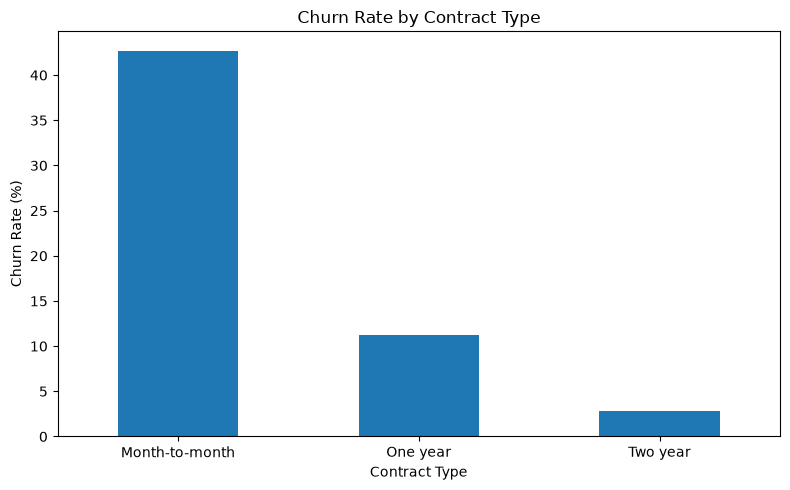

In [46]:
# Plot churn rate by contract type

plt.figure(figsize=(8, 5))

contract_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Finding

Month-to-month contract customers have the highest churn rate at 42.71%, followed by one-year contract customers at 11.27%. Two-year contract customers have the lowest churn rate at 2.83%. The substantial difference across contract types indicates that contract type is an important factor associated with customer churn.

In [47]:
# Calculate churn rate by internet service

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [48]:
# Extract churn percentage for each internet service

internet_churn_rate = internet_churn["Yes"].sort_values(ascending=False)

internet_churn_rate

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Yes, dtype: float64

### 4.2 Churn Rate by Internet Service

The churn rate is compared across internet service types to identify customer segments with higher churn.

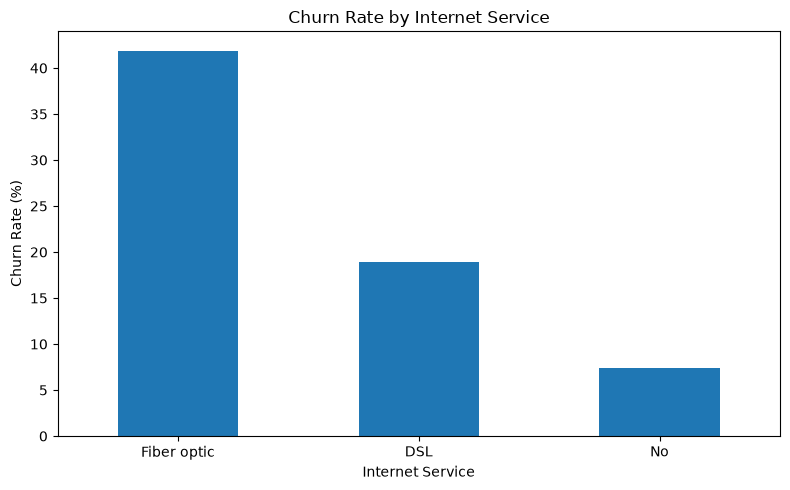

In [49]:
# Plot churn rate by internet service

plt.figure(figsize=(8, 5))

internet_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Finding

Fiber optic customers have the highest churn rate at 41.89%, followed by DSL customers at 18.96%. Customers without internet service have the lowest churn rate at 7.40%. The substantial difference in churn rates indicates that Internet Service is an important customer segment for further churn analysis.

In [50]:
# Calculate churn rate by payment method

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [51]:
# Extract churn percentage for each payment method

payment_churn_rate = payment_churn["Yes"].sort_values(ascending=False)

payment_churn_rate

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Yes, dtype: float64

### Finding

Electronic check customers have the highest churn rate at 45.29%, followed by mailed check customers at 19.11%. Customers using automatic bank transfer and automatic credit card payments have lower churn rates of 16.71% and 15.24%, respectively. This indicates that payment method is an important customer segment for further churn analysis.

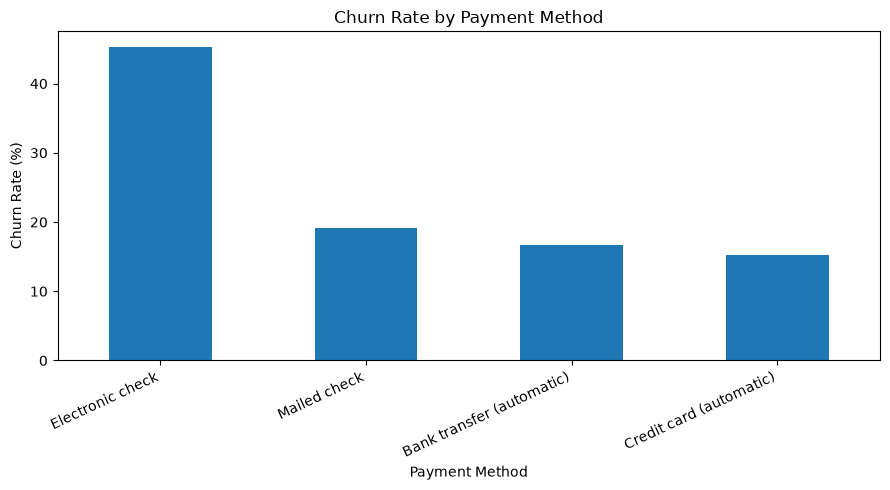

In [52]:
# Plot churn rate by payment method

plt.figure(figsize=(9, 5))

payment_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

## 5. Churn Rate by Tenure Group

Customers are grouped into tenure ranges to examine how churn behavior changes with the length of their relationship with the company.

In [53]:
# Create customer tenure groups

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

In [54]:
# Calculate churn rate by tenure group

tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


In [55]:
# Extract churn percentage for each tenure group

tenure_churn_rate = tenure_churn["Yes"]

tenure_churn_rate

TenureGroup
0-12 months     47.438243
13-24 months    28.710938
25-48 months    20.388959
49-72 months     9.513176
Name: Yes, dtype: float64

### Finding

Churn rate decreases substantially as customer tenure increases. Customers with 0–12 months of tenure have the highest churn rate at 47.44%, while customers with 49–72 months of tenure have the lowest churn rate at 9.51%. The results indicate that newer customers are considerably more likely to churn than long-term customers, making tenure an important variable for churn analysis and prediction.

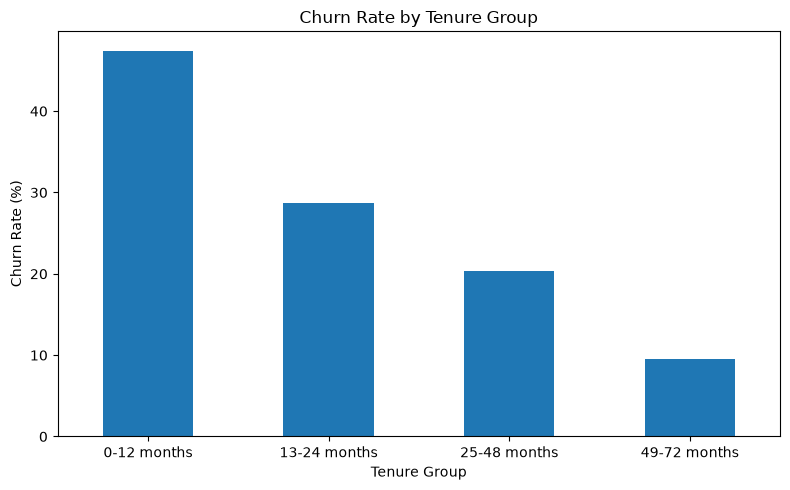

In [56]:
# Plot churn rate by tenure group

plt.figure(figsize=(8, 5))

tenure_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 6. Churn Rate by Monthly Charges

Customers are grouped by monthly charge ranges to examine whether churn behavior differs across different billing levels.

In [57]:
# Create monthly charge groups

df["MonthlyChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 70, 100, float("inf")],
    labels=["Low (18-40)", "Medium (40-70)", "High (70-100)", "Very High (100+)"]
)

df["MonthlyChargeGroup"].value_counts().sort_index()

MonthlyChargeGroup
Low (18-40)         1838
Medium (40-70)      1622
High (70-100)       2681
Very High (100+)     902
Name: count, dtype: int64

In [58]:
# Calculate churn rate by monthly charge group

monthly_charge_churn = pd.crosstab(
    df["MonthlyChargeGroup"],
    df["Churn"],
    normalize="index"
) * 100

monthly_charge_churn

Churn,No,Yes
MonthlyChargeGroup,,
Low (18-40),88.356910,11.643090
Medium (40-70),76.078915,23.921085
High (70-100),62.178292,37.821708
Very High (100+),71.951220,28.048780


In [59]:
# Extract churn percentage for each monthly charge group

monthly_charge_churn_rate = monthly_charge_churn["Yes"]

monthly_charge_churn_rate

MonthlyChargeGroup
Low (18-40)         11.643090
Medium (40-70)      23.921085
High (70-100)       37.821708
Very High (100+)    28.048780
Name: Yes, dtype: float64

### Finding

Churn rate generally increases with monthly charges up to the High (70-100) group. Customers in the High (70-100) group have the highest churn rate at 37.82%, while customers in the Low (18-40) group have the lowest churn rate at 11.64%. The Very High (100+) group has a lower churn rate of 28.05%, indicating that the relationship between monthly charges and churn is not completely linear.

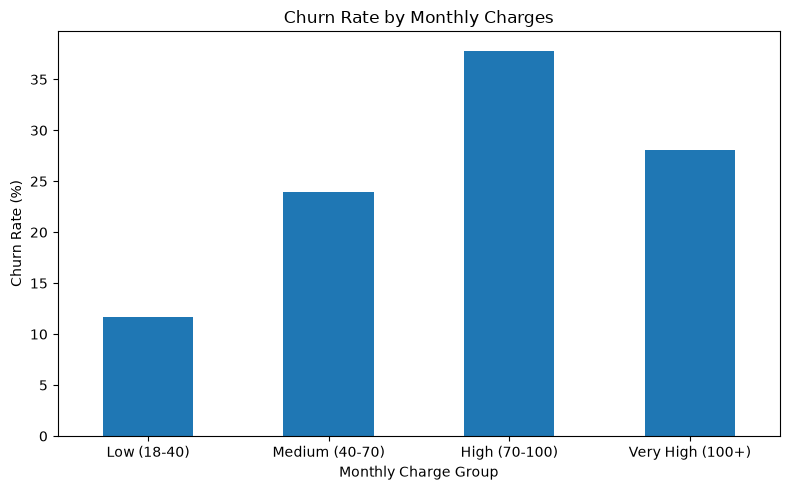

In [60]:
# Plot churn rate by monthly charge group

plt.figure(figsize=(8, 5))

monthly_charge_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 7. Day 3 Key Findings

The detailed customer segment analysis identified several important churn patterns:

- **Contract Type:** Month-to-month customers have the highest churn rate at 42.71%, while two-year contract customers have the lowest at 2.83%.

- **Internet Service:** Fiber optic customers have the highest churn rate at 41.89%, compared with 18.96% for DSL and 7.40% for customers without internet service.

- **Payment Method:** Electronic check customers have the highest churn rate at 45.29%, while automatic credit card payments have the lowest at 15.24%.

- **Tenure:** Churn decreases substantially as customer tenure increases. Customers with 0–12 months of tenure have a 47.44% churn rate, compared with 9.51% for customers with 49–72 months of tenure.

- **Monthly Charges:** Churn generally increases with monthly charges up to the 70–100 range. This group has the highest churn rate at 37.82%, while the 18–40 group has the lowest at 11.64%.

### Overall Observation

The analysis indicates that customer churn is particularly high among newer customers, month-to-month contract customers, fiber optic customers, electronic check users, and customers with higher monthly charges. These segments should receive further investigation during the next stages of the project.

## 8. Day 3 Conclusion

The detailed exploratory analysis identified several customer segments with noticeably different churn rates. Higher churn was observed among month-to-month contract customers, fiber optic customers, electronic check users, newer customers, and customers with higher monthly charges.

Tenure showed a particularly clear pattern, with churn decreasing as customer tenure increased. These findings provide useful direction for further analysis and will help identify important variables for the later churn prediction stage.

The analysis is exploratory and identifies associations between customer characteristics and churn; it does not establish causation.

# Customer Churn Prediction & LTV Engine

## Day 4 — Relationship Analysis & Feature Understanding

### Objectives

- Analyze the relationship between customer characteristics and churn.
- Compare churn rates across additional customer segments.
- Identify variables that may be useful for later churn prediction.
- Document important observations from the analysis.

## 1. Churn Rate by Senior Citizen Status

The churn rate is compared between senior and non-senior customers to determine whether customer age category is associated with churn.

In [61]:
# Calculate churn rate by senior citizen status

senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [62]:
# Extract churn percentage for each senior citizen group

senior_churn_rate = senior_churn["Yes"]

senior_churn_rate

SeniorCitizen
0    23.606168
1    41.681261
Name: Yes, dtype: float64

### Finding

Senior customers have a churn rate of 41.68%, compared with 23.61% for non-senior customers. The higher churn rate among senior customers indicates that SeniorCitizen status is associated with different churn behavior and may be useful for further churn analysis.

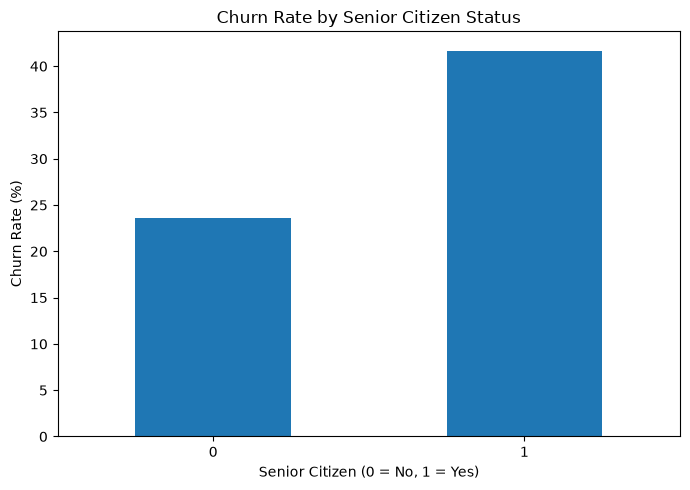

In [63]:
# Plot churn rate by senior citizen status

plt.figure(figsize=(7, 5))

senior_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 2. Churn Rate by Partner Status

The churn rate is compared between customers with and without a partner to identify differences in churn behavior.

In [64]:
# Calculate churn rate by partner status

partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

partner_churn

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


In [65]:
# Extract churn percentage for each partner group

partner_churn_rate = partner_churn["Yes"]

partner_churn_rate

Partner
No     32.957979
Yes    19.664903
Name: Yes, dtype: float64

### Finding

Customers without a partner have a churn rate of 32.96%, compared with 19.66% for customers with a partner. The higher churn rate among customers without a partner indicates that Partner status is associated with differences in customer churn behavior.

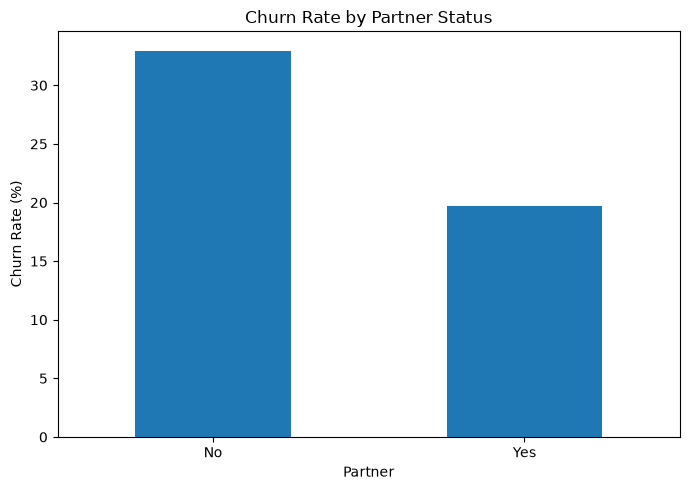

In [66]:
# Plot churn rate by partner status

plt.figure(figsize=(7, 5))

partner_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3. Churn Rate by Dependents

The churn rate is compared between customers with and without dependents to identify differences in churn behavior.

In [67]:
# Calculate churn rate by dependents status

dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

dependents_churn

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


In [68]:
# Extract churn percentage for each dependents group

dependents_churn_rate = dependents_churn["Yes"]

dependents_churn_rate

Dependents
No     31.279140
Yes    15.450237
Name: Yes, dtype: float64

### Finding

Customers without dependents have a churn rate of 31.28%, compared with 15.45% for customers with dependents. The higher churn rate among customers without dependents indicates that Dependents status is associated with differences in customer churn behavior.

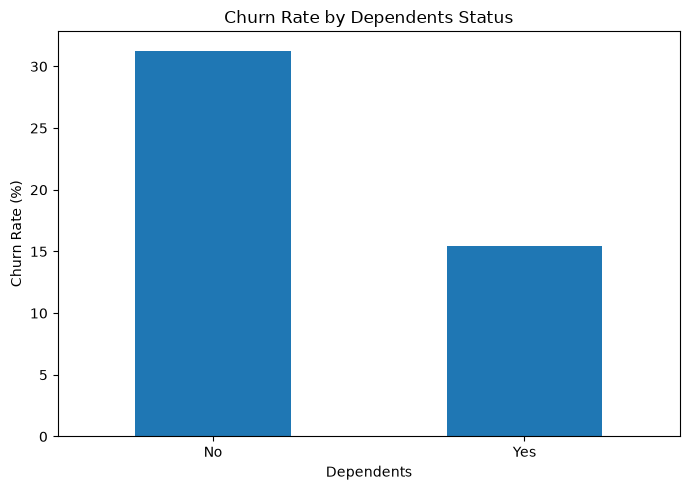

In [69]:
# Plot churn rate by dependents status

plt.figure(figsize=(7, 5))

dependents_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Dependents Status")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 4. Churn Rate by Phone Service

The churn rate is compared between customers with and without phone service to identify differences in churn behavior.

In [70]:
# Calculate churn rate by phone service

phone_churn = pd.crosstab(
    df["PhoneService"],
    df["Churn"],
    normalize="index"
) * 100

phone_churn

Churn,No,Yes
PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


In [71]:
# Extract churn percentage for each phone service group

phone_churn_rate = phone_churn["Yes"]

phone_churn_rate

PhoneService
No     24.926686
Yes    26.709637
Name: Yes, dtype: float64

### Finding

Customers with phone service have a churn rate of 26.71%, compared with 24.93% for customers without phone service. The difference is relatively small, indicating that PhoneService shows only a limited difference in churn rates in this dataset.

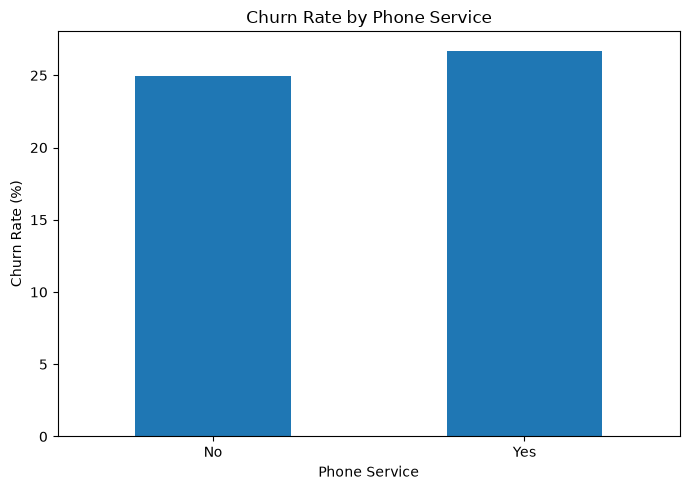

In [72]:
# Plot churn rate by phone service

plt.figure(figsize=(7, 5))

phone_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Phone Service")
plt.xlabel("Phone Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 5. Churn Rate by Paperless Billing

The churn rate is compared between customers using paperless billing and those using non-paperless billing to identify differences in churn behavior.

In [73]:
# Calculate churn rate by paperless billing

paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

paperless_churn

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


In [74]:
# Extract churn percentage for each paperless billing group

paperless_churn_rate = paperless_churn["Yes"]

paperless_churn_rate

PaperlessBilling
No     16.330084
Yes    33.565092
Name: Yes, dtype: float64

### Finding

Customers using paperless billing have a churn rate of 33.57%, compared with 16.33% for customers not using paperless billing. The noticeable difference indicates that PaperlessBilling is associated with different churn behavior in this dataset.

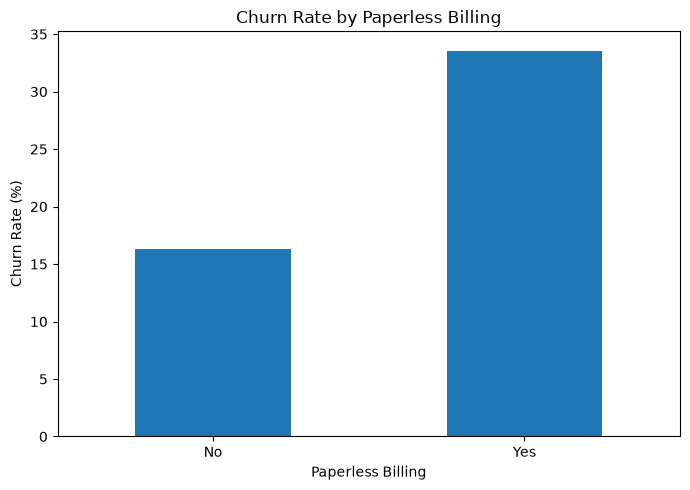

In [75]:
# Plot churn rate by paperless billing

plt.figure(figsize=(7, 5))

paperless_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 6. Day 4 Key Findings

The relationship analysis identified several differences in churn rates across customer characteristics:

- **Senior Citizen:** Senior customers have a higher churn rate of 41.68% compared with 23.61% for non-senior customers.

- **Partner:** Customers without a partner have a higher churn rate of 32.96% compared with 19.66% for customers with a partner.

- **Dependents:** Customers without dependents have a higher churn rate of 31.28% compared with 15.45% for customers with dependents.

- **Phone Service:** Churn rates are relatively similar for customers with and without phone service, at 26.71% and 24.93% respectively.

- **Paperless Billing:** Customers using paperless billing have a higher churn rate of 33.57% compared with 16.33% for customers not using paperless billing.

### Overall Observation

Senior Citizen status, Partner status, Dependents status, and Paperless Billing show noticeable differences in churn rates, while Phone Service shows only a small difference. These variables can be considered for further analysis and later churn prediction.

These observations describe associations in the dataset and do not establish causation.

## 7. Day 4 Conclusion

The relationship analysis showed that several customer characteristics are associated with different churn rates. Senior Citizen, Partner, Dependents, and Paperless Billing showed noticeable differences in churn behavior, while Phone Service showed only a small difference.

These findings help identify customer characteristics that may be useful for further churn analysis and the later prediction stage.

The analysis identifies associations in the dataset and does not establish causation.

# Day 5 — Service-Level Churn Analysis

This analysis examines customer churn across different service-related features. The objective is to identify service categories that show noticeable differences in churn rates and may be useful for further churn analysis and prediction.

## 1. Churn Rate by Internet Service

The churn rate is compared across different internet service types to identify differences in customer churn behavior.

In [76]:
# Calculate churn rate by internet service

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [77]:
# Extract churn percentage for each internet service

internet_churn_rate = internet_churn["Yes"]

internet_churn_rate.sort_values(ascending=False)

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Yes, dtype: float64

### Finding

Customers using fiber optic internet have the highest churn rate at 41.89%, followed by DSL customers at 18.96%. Customers without internet service have the lowest churn rate at 7.40%. This shows a noticeable difference in churn rates across internet service types.

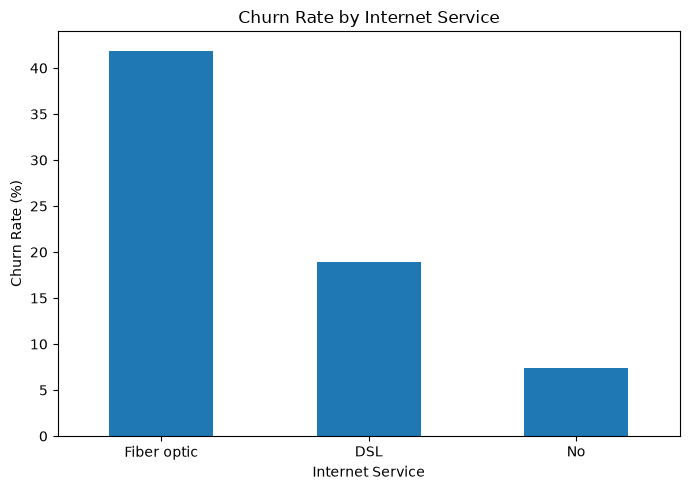

In [78]:
# Plot churn rate by internet service

plt.figure(figsize=(7, 5))

internet_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 2. Churn Rate by Online Security

The churn rate is compared between customers with and without online security to identify differences in churn behavior.

In [79]:
# Calculate churn rate by online security

online_security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

online_security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [80]:
# Extract churn percentage for each online security group

online_security_churn_rate = online_security_churn["Yes"]

online_security_churn_rate.sort_values(ascending=False)

OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Yes, dtype: float64

### Finding

Customers without online security have the highest churn rate at 41.77%, compared with 14.61% for customers with online security. Customers without internet service have the lowest churn rate at 7.40%. This shows a noticeable difference in churn rates across online security categories.

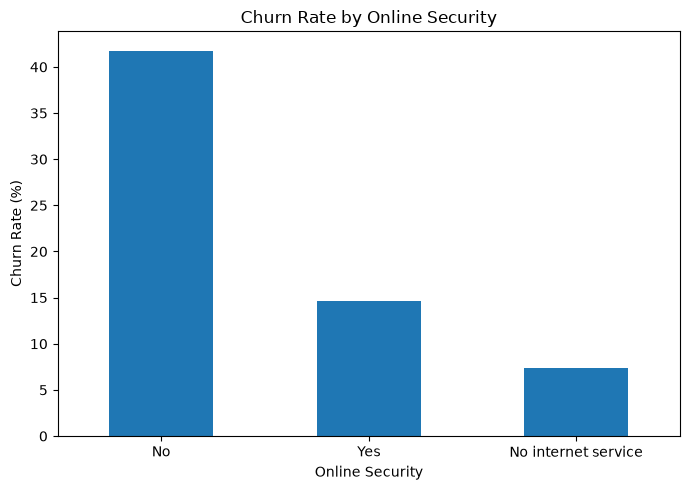

In [81]:
# Plot churn rate by online security

plt.figure(figsize=(7, 5))

online_security_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3. Churn Rate by Online Backup

The churn rate is compared between customers with and without online backup to identify differences in churn behavior.

In [82]:
# Calculate churn rate by online backup

online_backup_churn = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

online_backup_churn

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


In [83]:
# Extract churn percentage for each online backup group

online_backup_churn_rate = online_backup_churn["Yes"]

online_backup_churn_rate.sort_values(ascending=False)

OnlineBackup
No                     39.928756
Yes                    21.531494
No internet service     7.404980
Name: Yes, dtype: float64

### Finding

Customers without online backup have the highest churn rate at 39.93%, compared with 21.53% for customers with online backup. Customers without internet service have the lowest churn rate at 7.40%. This shows a noticeable difference in churn rates across online backup categories.

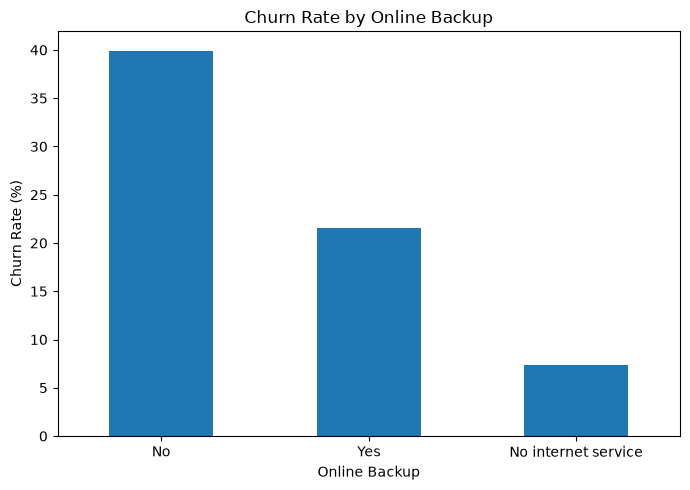

In [84]:
# Plot churn rate by online backup

plt.figure(figsize=(7, 5))

online_backup_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 4. Churn Rate by Device Protection

The churn rate is compared between customers with and without device protection to identify differences in churn behavior.

In [85]:
# Calculate churn rate by device protection

device_protection_churn = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

device_protection_churn

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


In [86]:
# Extract churn percentage for each device protection group

device_protection_churn_rate = device_protection_churn["Yes"]

device_protection_churn_rate.sort_values(ascending=False)

DeviceProtection
No                     39.127625
Yes                    22.502064
No internet service     7.404980
Name: Yes, dtype: float64

### Finding

Customers without device protection have the highest churn rate at 39.13%, compared with 22.50% for customers with device protection. Customers without internet service have the lowest churn rate at 7.40%. This shows a noticeable difference in churn rates across device protection categories.

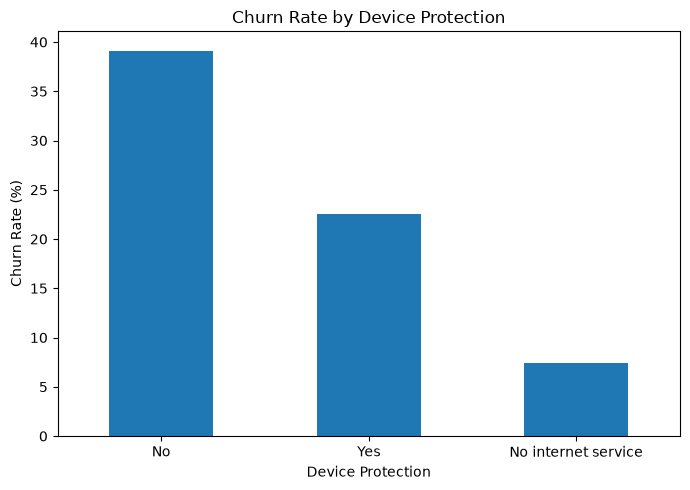

In [87]:
# Plot churn rate by device protection

plt.figure(figsize=(7, 5))

device_protection_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 5. Churn Rate by Tech Support

The churn rate is compared between customers with and without technical support to identify differences in churn behavior.

In [88]:
# Calculate churn rate by tech support

tech_support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

tech_support_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [89]:
# Extract churn percentage for each tech support group

tech_support_churn_rate = tech_support_churn["Yes"]

tech_support_churn_rate.sort_values(ascending=False)

TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Yes, dtype: float64

### Finding

Customers without tech support have the highest churn rate at 41.64%, compared with 15.17% for customers with tech support. Customers without internet service have the lowest churn rate at 7.40%. This shows a noticeable difference in churn rates across tech support categories.

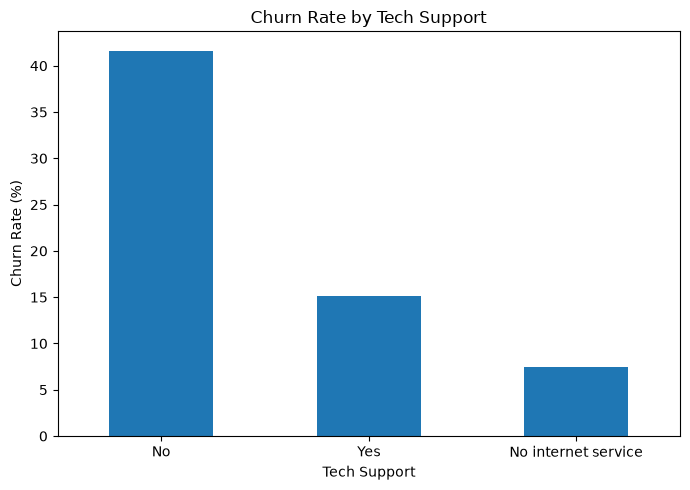

In [90]:
# Plot churn rate by tech support

plt.figure(figsize=(7, 5))

tech_support_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 6. Churn Rate by Streaming TV

The churn rate is compared between customers with and without streaming TV to identify differences in churn behavior.

In [91]:
# Calculate churn rate by streaming TV

streaming_tv_churn = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

streaming_tv_churn

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


In [92]:
# Extract churn percentage for each streaming TV group

streaming_tv_churn_rate = streaming_tv_churn["Yes"]

streaming_tv_churn_rate.sort_values(ascending=False)

StreamingTV
No                     33.523132
Yes                    30.070188
No internet service     7.404980
Name: Yes, dtype: float64

### Finding

Customers without streaming TV have a churn rate of 33.52%, compared with 30.07% for customers with streaming TV. Customers without internet service have the lowest churn rate at 7.40%. The difference between customers with and without streaming TV is relatively small.

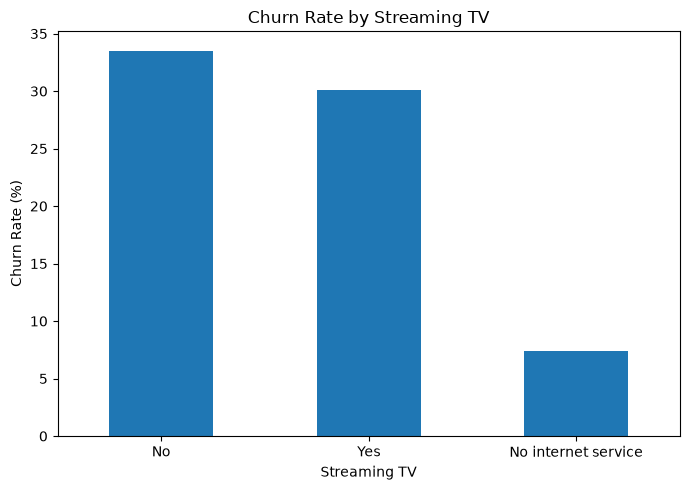

In [93]:
# Plot churn rate by streaming TV

plt.figure(figsize=(7, 5))

streaming_tv_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 7. Churn Rate by Streaming Movies

The churn rate is compared between customers with and without streaming movies to identify differences in churn behavior.

In [94]:
# Calculate churn rate by streaming movies

streaming_movies_churn = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

streaming_movies_churn

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


In [95]:
# Extract churn percentage for each streaming movies group

streaming_movies_churn_rate = streaming_movies_churn["Yes"]

streaming_movies_churn_rate.sort_values(ascending=False)

StreamingMovies
No                     33.680431
Yes                    29.941435
No internet service     7.404980
Name: Yes, dtype: float64

### Finding

Customers without streaming movies have a churn rate of 33.68%, compared with 29.94% for customers with streaming movies. Customers without internet service have the lowest churn rate at 7.40%. The difference between customers with and without streaming movies is relatively small.

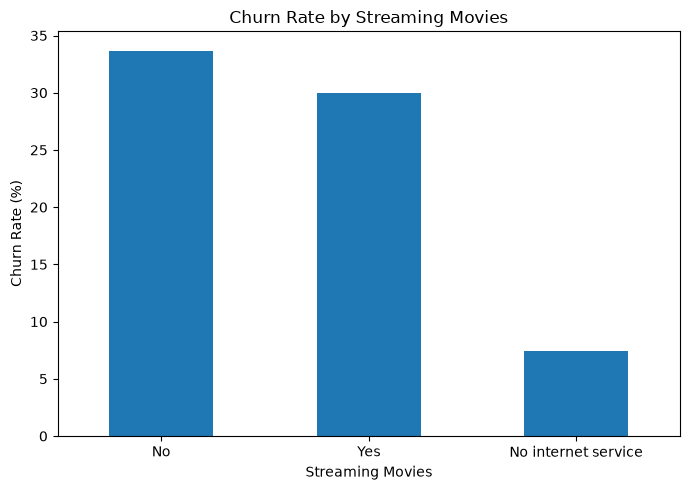

In [96]:
# Plot churn rate by streaming movies

plt.figure(figsize=(7, 5))

streaming_movies_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Streaming Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 8. Day 5 Key Findings

The service-level analysis identified several noticeable differences in customer churn rates:

- **Internet Service:** Fiber optic customers have the highest churn rate at 41.89%, while customers without internet service have the lowest rate at 7.40%.

- **Online Security:** Customers without online security have a churn rate of 41.77%, compared with 14.61% for customers with online security.

- **Online Backup:** Customers without online backup have a churn rate of 39.93%, compared with 21.53% for customers with online backup.

- **Device Protection:** Customers without device protection have a churn rate of 39.13%, compared with 22.50% for customers with device protection.

- **Tech Support:** Customers without tech support have a churn rate of 41.64%, compared with 15.17% for customers with tech support.

- **Streaming TV:** Customers without streaming TV have a churn rate of 33.52%, compared with 30.07% for customers with streaming TV.

- **Streaming Movies:** Customers without streaming movies have a churn rate of 33.68%, compared with 29.94% for customers with streaming movies.

### Overall Observation

The largest differences in churn rates are observed for Internet Service, Online Security, Online Backup, Device Protection, and Tech Support. Customers lacking these additional services generally show higher churn rates. Streaming TV and Streaming Movies show smaller differences between customers with and without the services.

These findings describe associations in the dataset and do not establish causation.

## 9. Day 5 Conclusion

The service-level analysis showed that several additional services are associated with noticeable differences in customer churn rates. Internet Service, Online Security, Online Backup, Device Protection, and Tech Support showed particularly large differences between customer groups.

Customers without these additional services generally showed higher churn rates, while Streaming TV and Streaming Movies showed relatively smaller differences.

These findings provide useful features for further analysis and can help guide the later customer churn prediction stage.

The analysis identifies associations in the dataset and does not establish causation.

# Day 6 — Churn Feature Comparison

This analysis compares the churn rates across important customer and service-related features identified during the previous exploratory analyses. The objective is to identify variables that show noticeable differences in churn behavior and may be useful for the later churn prediction stage.

## 1. Comparison of Key Churn Rates

The churn rates from the previous analyses are combined to compare the variables that show the largest differences between customer groups.

In [97]:
# Create a summary of important churn rates

feature_churn_summary = {
    "Internet Service": internet_churn_rate,
    "Online Security": online_security_churn_rate,
    "Online Backup": online_backup_churn_rate,
    "Device Protection": device_protection_churn_rate,
    "Tech Support": tech_support_churn_rate,
    "Streaming TV": streaming_tv_churn_rate,
    "Streaming Movies": streaming_movies_churn_rate,
    "Contract": contract_churn_rate,
    "Payment Method": payment_churn_rate,
    "Tenure Group": tenure_churn_rate,
    "Monthly Charge Group": monthly_charge_churn_rate
}

feature_churn_summary

{'Internet Service': InternetService
 DSL            18.959108
 Fiber optic    41.892765
 No              7.404980
 Name: Yes, dtype: float64,
 'Online Security': OnlineSecurity
 No                     41.766724
 No internet service     7.404980
 Yes                    14.611194
 Name: Yes, dtype: float64,
 'Online Backup': OnlineBackup
 No                     39.928756
 No internet service     7.404980
 Yes                    21.531494
 Name: Yes, dtype: float64,
 'Device Protection': DeviceProtection
 No                     39.127625
 No internet service     7.404980
 Yes                    22.502064
 Name: Yes, dtype: float64,
 'Tech Support': TechSupport
 No                     41.635474
 No internet service     7.404980
 Yes                    15.166341
 Name: Yes, dtype: float64,
 'Streaming TV': StreamingTV
 No                     33.523132
 No internet service     7.404980
 Yes                    30.070188
 Name: Yes, dtype: float64,
 'Streaming Movies': StreamingMovies
 No    

In [98]:
# Create a clean table of churn rates

comparison_data = []

for feature, rates in feature_churn_summary.items():
    for category, churn_rate in rates.items():
        comparison_data.append({
            "Feature": feature,
            "Category": category,
            "Churn Rate (%)": round(churn_rate, 2)
        })

feature_comparison = pd.DataFrame(comparison_data)

feature_comparison

,Feature,Category,Churn Rate (%)
0,Internet Service,DSL,18.96
1,Internet Service,Fiber optic,41.89
2,Internet Service,No,7.40
3,Online Security,No,41.77
4,Online Security,No internet service,7.40
5,Online Security,Yes,14.61
6,Online Backup,No,39.93
7,Online Backup,No internet service,7.40
8,Online Backup,Yes,21.53
9,Device Protection,No,39.13


In [99]:
# Find the highest churn category for each feature

highest_churn_by_feature = (
    feature_comparison
    .loc[feature_comparison.groupby("Feature")["Churn Rate (%)"].idxmax()]
    .sort_values("Churn Rate (%)", ascending=False)
)

highest_churn_by_feature

,Feature,Category,Churn Rate (%)
28,Tenure Group,0-12 months,47.44
24,Payment Method,Electronic check,45.29
21,Contract,Month-to-month,42.71
1,Internet Service,Fiber optic,41.89
3,Online Security,No,41.77
12,Tech Support,No,41.64
6,Online Backup,No,39.93
9,Device Protection,No,39.13
34,Monthly Charge Group,High (70-100),37.82
18,Streaming Movies,No,33.68


In [100]:
# Calculate the difference between highest and lowest churn rate for each feature

feature_churn_range = (
    feature_comparison
    .groupby("Feature")["Churn Rate (%)"]
    .agg(["min", "max"])
)

feature_churn_range["Churn Rate Difference (%)"] = (
    feature_churn_range["max"] - feature_churn_range["min"]
)

feature_churn_range = feature_churn_range.sort_values(
    "Churn Rate Difference (%)",
    ascending=False
)

feature_churn_range

,min,max,Churn Rate Difference (%)
Feature,,,
Contract,2.83,42.71,39.88
Tenure Group,9.51,47.44,37.93
Internet Service,7.40,41.89,34.49
Online Security,7.40,41.77,34.37
Tech Support,7.40,41.64,34.24
Online Backup,7.40,39.93,32.53
Device Protection,7.40,39.13,31.73
Payment Method,15.24,45.29,30.05
Streaming Movies,7.40,33.68,26.28


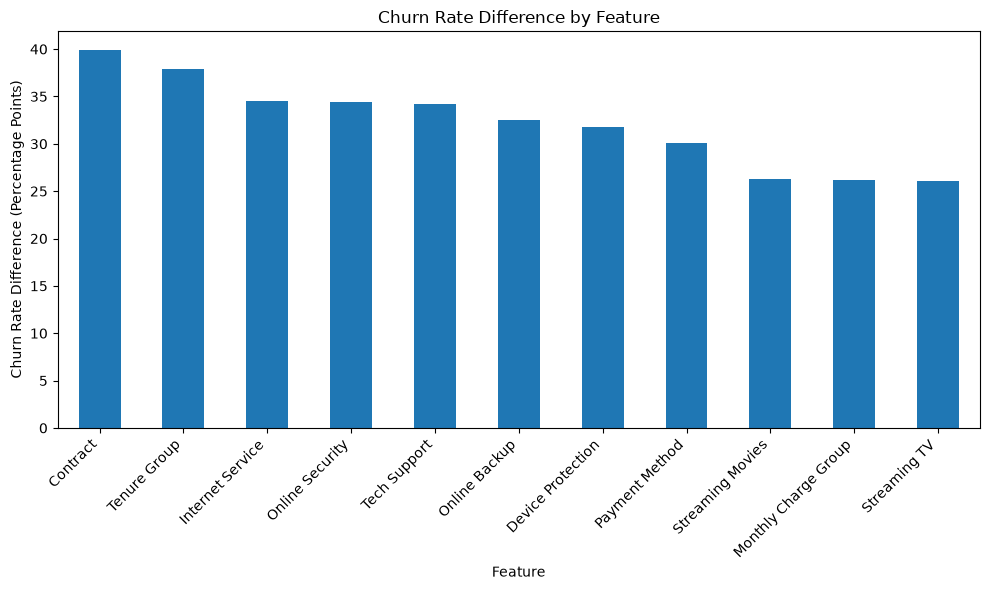

In [101]:
# Plot churn-rate difference by feature

plt.figure(figsize=(10, 6))

feature_churn_range["Churn Rate Difference (%)"].plot(kind="bar")

plt.title("Churn Rate Difference by Feature")
plt.xlabel("Feature")
plt.ylabel("Churn Rate Difference (Percentage Points)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 6. Day 6 Key Findings

The feature comparison showed noticeable differences in churn rates across the analyzed customer and service-related features.

- Contract showed the largest churn-rate difference of 39.88 percentage points, with month-to-month customers having the highest churn rate.
- Tenure Group showed the second-largest difference of 37.93 percentage points, with customers having 0–12 months of tenure showing the highest churn rate.
- Internet Service showed a difference of 34.49 percentage points, with fiber optic customers having the highest churn rate.
- Online Security and Tech Support also showed large differences in churn rates, with customers without these services showing higher churn rates.
- Online Backup and Device Protection showed similar patterns, where customers without these services had higher churn rates.
- Streaming TV and Streaming Movies showed comparatively smaller differences in churn rates.

Overall, Contract, Tenure Group, Internet Service, Online Security, and Tech Support show particularly noticeable differences in churn behavior and may be useful for further churn analysis and prediction.

These findings describe associations in the dataset and do not establish causation.

## 7. Day 6 Conclusion

The feature comparison analysis identified several variables with noticeable differences in churn rates across their categories. Contract and Tenure Group showed the largest churn-rate differences, followed by Internet Service, Online Security, and Tech Support.

These features show useful patterns in customer churn behavior and can be considered important candidates for the later churn prediction stage.

The analysis is exploratory and identifies associations in the dataset; it does not establish causation.

# Day 7 — Statistical Validation of Churn Factors

The previous exploratory analysis identified several customer and service-related features with noticeable differences in churn rates. Statistical testing is now performed to determine whether the observed relationships between selected categorical features and churn are statistically significant.

The Chi-square test of independence is used because both the feature variables and churn status are categorical.

## 1. Chi-square Test: Contract vs Churn

The relationship between customer contract type and churn status is tested using the Chi-square test of independence.

In [102]:
# Import chi-square test

from scipy.stats import chi2_contingency

In [103]:
# Create contingency table for Contract and Churn

contract_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_table

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [104]:
# Perform Chi-square test

chi2, p_value, dof, expected = chi2_contingency(contract_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 1184.5965720837926
p-value: 5.863038300673391e-258
Degrees of freedom: 2


### Interpretation

The p-value is far below the significance level of 0.05. Therefore, the null hypothesis is rejected.

This indicates a statistically significant association between Contract type and Churn status in the dataset.

The result supports the exploratory finding that churn behavior differs across contract types.

The Chi-square test identifies an association and does not establish causation.

**H₀:** Contract type and Churn are independent.

**H₁:** Contract type and Churn are associated.

**Decision:** Reject H₀ because p-value < 0.05.

## 2. Chi-square Test: Tenure Group vs Churn

The relationship between customer tenure group and churn status is tested using the Chi-square test of independence.

In [105]:
# Create contingency table for Tenure Group and Churn

tenure_table = pd.crosstab(
    df["TenureGroup"],
    df["Churn"]
)

tenure_table

Churn,No,Yes
TenureGroup,,
0-12 months,1149,1037
13-24 months,730,294
25-48 months,1269,325
49-72 months,2026,213


In [106]:
# Perform Chi-square test

chi2, p_value, dof, expected = chi2_contingency(tenure_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 856.1002388751685
p-value: 2.9437703649803846e-185
Degrees of freedom: 3


### Interpretation

The p-value is far below the significance level of 0.05. Therefore, the null hypothesis is rejected.

This indicates a statistically significant association between Tenure Group and Churn status in the dataset.

The result supports the exploratory finding that churn behavior differs across customer tenure groups.

The Chi-square test identifies an association and does not establish causation.

**H₀:** Tenure Group and Churn are independent.

**H₁:** Tenure Group and Churn are associated.

**Decision:** Reject H₀ because p-value < 0.05.

## 3. Chi-square Test: Internet Service vs Churn

The relationship between Internet Service and churn status is tested using the Chi-square test of independence.

In [107]:
# Create contingency table for Internet Service and Churn

internet_table = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

internet_table

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [108]:
# Perform Chi-square test

chi2, p_value, dof, expected = chi2_contingency(internet_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 732.309589667794
p-value: 9.571788222840544e-160
Degrees of freedom: 2


### Interpretation

The p-value is far below the significance level of 0.05. Therefore, the null hypothesis is rejected.

This indicates a statistically significant association between Internet Service and Churn status in the dataset.

The result supports the exploratory finding that churn behavior differs across Internet Service categories.

The Chi-square test identifies an association and does not establish causation.

**H₀:** Internet Service and Churn are independent.

**H₁:** Internet Service and Churn are associated.

**Decision:** Reject H₀ because p-value < 0.05.

## 4. Chi-square Test: Online Security vs Churn

The relationship between Online Security and churn status is tested using the Chi-square test of independence.

In [109]:
# Create contingency table for Online Security and Churn

security_table = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"]
)

security_table

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


In [110]:
# Perform Chi-square test

chi2, p_value, dof, expected = chi2_contingency(security_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 849.9989679615965
p-value: 2.661149635176552e-185
Degrees of freedom: 2


### Interpretation

The p-value is far below the significance level of 0.05. Therefore, the null hypothesis is rejected.

This indicates a statistically significant association between Online Security and Churn status in the dataset.

The result supports the exploratory finding that churn behavior differs across Online Security categories.

The Chi-square test identifies an association and does not establish causation.

**H₀:** Online Security and Churn are independent.

**H₁:** Online Security and Churn are associated.

**Decision:** Reject H₀ because p-value < 0.05.

## 5. Chi-square Test: Tech Support vs Churn

The relationship between Tech Support and churn status is tested using the Chi-square test of independence.

In [111]:
# Create contingency table for Tech Support and Churn

tech_support_table = pd.crosstab(
    df["TechSupport"],
    df["Churn"]
)

tech_support_table

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


In [112]:
# Perform Chi-square test

chi2, p_value, dof, expected = chi2_contingency(tech_support_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 828.1970684587394
p-value: 1.4430840279998987e-180
Degrees of freedom: 2


### Interpretation

The p-value is far below the significance level of 0.05. Therefore, the null hypothesis is rejected.

This indicates a statistically significant association between Tech Support and Churn status in the dataset.

The result supports the exploratory finding that churn behavior differs across Tech Support categories.

The Chi-square test identifies an association and does not establish causation.

**H₀:** Tech Support and Churn are independent.

**H₁:** Tech Support and Churn are associated.

**Decision:** Reject H₀ because p-value < 0.05.

## 6. Chi-square Test Summary

The results of the Chi-square tests for the selected customer and service-related features are summarized below.

In [113]:
# Create summary table of Chi-square test results

chi_square_summary = pd.DataFrame({
    "Feature": [
        "Contract",
        "Tenure Group",
        "Internet Service",
        "Online Security",
        "Tech Support"
    ],
    "Chi-square Statistic": [
        1184.5965720837926,
        856.1002388751685,
        732.309589667794,
        849.9989679615965,
        828.1970684587394
    ],
    "p-value": [
        5.863038300673391e-258,
        2.9437703649803846e-185,
        9.57178882405454e-160,
        2.661149635176552e-185,
        1.443084027999897e-180
    ],
    "Degrees of Freedom": [
        2,
        3,
        2,
        2,
        2
    ]
})

chi_square_summary

,Feature,Chi-square Statistic,p-value,Degrees of Freedom
0,Contract,1184.596572,5.863038e-258,2
1,Tenure Group,856.100239,2.943770e-185,3
2,Internet Service,732.309590,9.571789e-160,2
3,Online Security,849.998968,2.661150e-185,2
4,Tech Support,828.197068,1.443084e-180,2


In [114]:
# Add significance decision

chi_square_summary["Significant (p < 0.05)"] = (
    chi_square_summary["p-value"] < 0.05
)

chi_square_summary

,Feature,Chi-square Statistic,p-value,Degrees of Freedom,Significant (p < 0.05)
0,Contract,1184.596572,5.863038e-258,2,True
1,Tenure Group,856.100239,2.943770e-185,3,True
2,Internet Service,732.309590,9.571789e-160,2,True
3,Online Security,849.998968,2.661150e-185,2,True
4,Tech Support,828.197068,1.443084e-180,2,True


## 7. Day 7 Conclusion

The Chi-square tests showed statistically significant associations between Churn and all five selected features: Contract, Tenure Group, Internet Service, Online Security, and Tech Support.

For all tested features, the p-value was below the significance level of 0.05, so the null hypothesis of independence was rejected.

Among the tested variables, Contract had the highest Chi-square statistic, followed by Tenure Group, Online Security, Tech Support, and Internet Service.

These results provide statistical support for the patterns observed during the exploratory analysis and help identify important variables for the later churn prediction stage.

The Chi-square test identifies association between categorical variables and does not establish causation.

# Day 8 — Data Preparation for Churn Prediction

The exploratory and statistical analyses identified several customer characteristics associated with churn. The next step is to prepare the dataset for machine learning by defining the target variable, separating features from the target, identifying categorical and numerical variables, and preparing the data for model development.

## 1. Check Churn Distribution

Before building a prediction model, the target variable is reviewed to understand the distribution of customers who churned and those who remained.

In [115]:
# Check churn distribution

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [116]:
# Check churn percentage

df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## 2. Convert Churn into Numeric Values

The Churn target is converted into binary values, where 0 represents customers who did not churn and 1 represents customers who churned.

In [117]:
# Convert Churn into binary values

df["Churn_Encoded"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn_Encoded"].value_counts()

Churn_Encoded
0    5174
1    1869
Name: count, dtype: int64

In [118]:
df[["Churn", "Churn_Encoded"]].head()

,Churn,Churn_Encoded
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


## 3. Separate Features and Target

The customer attributes are treated as input features, while the encoded Churn variable is used as the prediction target.

In [119]:
# Define features and target

X = df.drop(columns=["Churn", "Churn_Encoded"])
y = df["Churn_Encoded"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 22)
Target shape: (7043,)


In [120]:
# Identify numerical and categorical columns

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X.select_dtypes(include=["object", "category"]).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup', 'MonthlyChargeGroup']


C:\Users\HP\AppData\Local\Temp\ipykernel_18140\4225004081.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object", "category"]).columns


In [121]:
# Remove customer ID because it is only an identifier

X = X.drop(columns=["customerID"])

print("Updated feature shape:", X.shape)

Updated feature shape: (7043, 21)


In [122]:
# Re-identify numerical and categorical columns

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup', 'MonthlyChargeGroup']


C:\Users\HP\AppData\Local\Temp\ipykernel_18140\3732534484.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


## 4. Train-Test Split

The dataset is divided into training and testing sets. The training data will be used to build the churn prediction model, while the testing data will be used to evaluate its performance on unseen customers.

In [123]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5634, 21)
Testing features: (1409, 21)
Training target: (5634,)
Testing target: (1409,)


## 5. Encode Categorical Variables

Machine-learning models require numerical input. Therefore, categorical variables are converted into numerical values using one-hot encoding.

The numerical variables are kept as numerical values.

In [124]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns),
        ("num", "passthrough", numerical_columns)
    ]
)

# Fit preprocessing only on training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Apply the same transformation to test data
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (5634, 53)
Encoded testing shape: (1409, 53)


In [125]:
print("Training data type:", X_train_encoded.dtype)
print("Testing data type:", X_test_encoded.dtype)

Training data type: float64
Testing data type: float64


## 6. Check Target Balance

The distribution of churn and non-churn customers in the training data is checked before model development. This helps determine whether the target classes are balanced or imbalanced.

In [126]:
# Check target distribution in training data

print("Training target distribution:")
print(y_train.value_counts())

print("\nTraining target percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training target distribution:
Churn_Encoded
0    4139
1    1495
Name: count, dtype: int64

Training target percentage:
Churn_Encoded
0    73.46
1    26.54
Name: proportion, dtype: float64


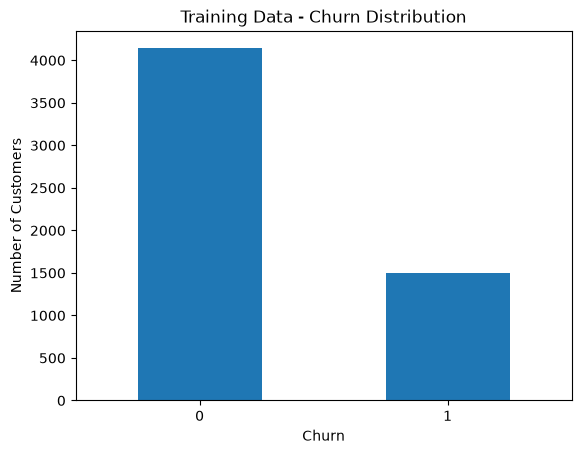

In [127]:
# Plot target distribution

y_train.value_counts().plot(
    kind="bar",
    title="Training Data - Churn Distribution"
)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

## 7. Day 8 Conclusion

The dataset was successfully prepared for machine learning. The target variable Churn was converted into a binary numerical variable, with 0 representing customers who did not churn and 1 representing customers who churned.

The customer ID was removed because it is an identifier and does not provide useful predictive information.

The dataset was divided into training and testing sets using an 80:20 split with stratification. Categorical variables were converted into numerical features using one-hot encoding.

The training dataset contains 5,634 customers and the testing dataset contains 1,409 customers. After encoding, the feature set contains 53 numerical features.

The target variable is imbalanced, with 73.46% non-churn customers and 26.54% churn customers. Therefore, model evaluation should consider metrics such as precision, recall, F1-score, and ROC-AUC rather than relying only on accuracy.

The prepared dataset is ready for the next stage of churn prediction model development.

# Day 9 — Churn Prediction Model

The dataset has been prepared for machine learning through feature selection, train-test splitting, and categorical encoding. In this stage, a baseline classification model is developed to predict customer churn.

Logistic Regression is used as the first baseline model because the target variable is binary, where 0 represents non-churn and 1 represents churn.

## 1. Baseline Model — Logistic Regression

Logistic Regression is used as the first baseline classification model for predicting customer churn.

In [128]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print(logistic_model)

LogisticRegression(max_iter=1000, random_state=42)


In [129]:
# Train the Logistic Regression model

logistic_model.fit(
    X_train_encoded,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


c:\Users\HP\customer-churn-LTV-engine\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 2. Generate Churn Predictions

The trained model is used to predict churn outcomes for the unseen testing dataset.

In [130]:
# Predict churn for the test dataset

y_pred = logistic_model.predict(X_test_encoded)

print("Predictions generated:", len(y_pred))
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated: 1409
First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [131]:
from sklearn.metrics import accuracy_score

# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Accuracy (%):", round(accuracy * 100, 2))

Accuracy: 0.7991
Accuracy (%): 79.91


## 3. Confusion Matrix

The confusion matrix is used to understand how the model classifies churn and non-churn customers. It shows true positives, true negatives, false positives, and false negatives.

In [132]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[933 102]
 [181 193]]


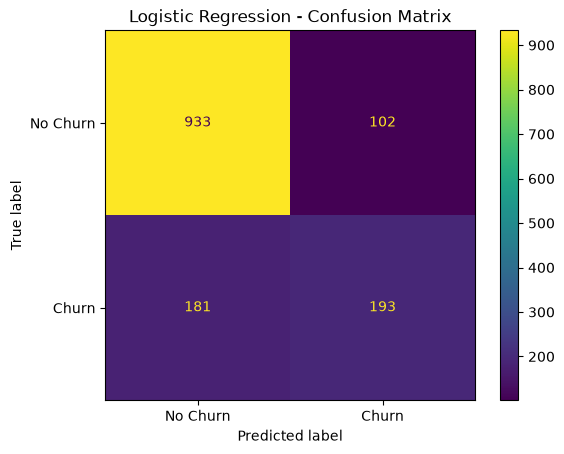

In [133]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display confusion matrix

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [134]:
from sklearn.metrics import classification_report

# Generate classification report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## 4. ROC-AUC Evaluation

ROC-AUC is used to evaluate the model's ability to distinguish between churn and non-churn customers across different classification thresholds.

In [135]:
from sklearn.metrics import roc_auc_score

# Predict churn probabilities

y_pred_proba = logistic_model.predict_proba(X_test_encoded)[:, 1]

# Calculate ROC-AUC

roc_auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.8428


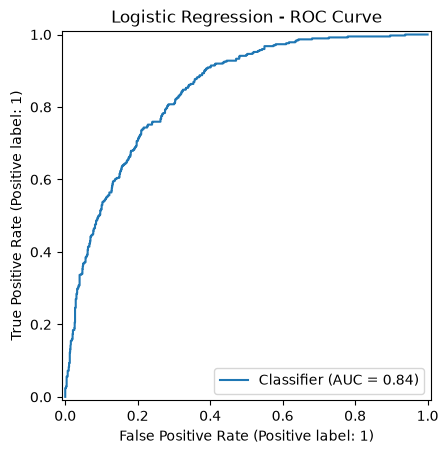

In [136]:
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba
)

plt.title("Logistic Regression - ROC Curve")
plt.show()

## 5. Day 9 Conclusion

A Logistic Regression model was developed as the baseline churn prediction model.

The model achieved an accuracy of 79.91% and a ROC-AUC score of 0.8428 on the test dataset. For the Churn class, the model achieved a precision of 65%, recall of 52%, and F1-score of 58%.

The confusion matrix showed that the model correctly identified 193 churn customers but missed 181 actual churn customers.

The ROC-AUC result indicates that the model has good ability to distinguish between churn and non-churn customers. However, the relatively lower recall for the Churn class indicates that there is scope for improving the model's ability to identify customers who are likely to churn.

This Logistic Regression model will serve as the baseline for comparison with more advanced churn prediction models in later stages.

The evaluation uses multiple metrics rather than accuracy alone because the target variable is imbalanced.

# Day 10 — Improving the Churn Prediction Model

The Day 9 Logistic Regression model achieved an accuracy of 79.91% and a ROC-AUC score of 0.8428. However, the recall for the Churn class was 52%, indicating that a considerable number of actual churn customers were not identified.

Since the target variable is imbalanced, a class-weighted Logistic Regression model is tested to give greater importance to the minority Churn class.

## 1. Class-Weighted Logistic Regression

Class weighting is used to give more importance to the minority Churn class during model training. This may improve the model's ability to identify customers who are likely to churn.

In [137]:
from sklearn.linear_model import LogisticRegression

# Create class-weighted Logistic Regression model

weighted_logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

print(weighted_logistic_model)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


In [138]:
# Train the class-weighted model

weighted_logistic_model.fit(
    X_train_encoded,
    y_train
)

print("Class-weighted Logistic Regression trained successfully.")

Class-weighted Logistic Regression trained successfully.


c:\Users\HP\customer-churn-LTV-engine\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [139]:
# Generate predictions

y_pred_weighted = weighted_logistic_model.predict(
    X_test_encoded
)

print("Predictions generated:", len(y_pred_weighted))

Predictions generated: 1409


In [140]:
from sklearn.metrics import classification_report

print("Class-Weighted Logistic Regression:")
print(
    classification_report(
        y_test,
        y_pred_weighted,
        target_names=["No Churn", "Churn"]
    )
)

Class-Weighted Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [141]:
from sklearn.metrics import roc_auc_score

# Predict churn probabilities for the weighted model

y_pred_proba_weighted = weighted_logistic_model.predict_proba(
    X_test_encoded
)[:, 1]

# Calculate ROC-AUC

roc_auc_weighted = roc_auc_score(
    y_test,
    y_pred_proba_weighted
)

print("Weighted Logistic Regression ROC-AUC:",
      round(roc_auc_weighted, 4))

Weighted Logistic Regression ROC-AUC: 0.8427


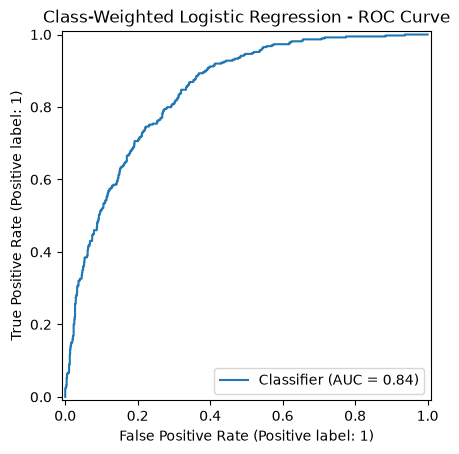

In [142]:
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve for weighted Logistic Regression

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba_weighted
)

plt.title("Class-Weighted Logistic Regression - ROC Curve")
plt.show()

## 2. Model Comparison

The baseline Logistic Regression model is compared with the class-weighted Logistic Regression model to evaluate the effect of handling class imbalance.

In [143]:
# Create model comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Class-Weighted Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        accuracy_score(y_test, y_pred_weighted)
    ],
    "Churn Precision": [
        0.65,
        0.51
    ],
    "Churn Recall": [
        0.52,
        0.79
    ],
    "Churn F1": [
        0.58,
        0.62
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_weighted
    ]
})

model_comparison

,Model,Accuracy,Churn Precision,Churn Recall,Churn F1,ROC-AUC
0,Logistic Regression,0.799148,0.65,0.52,0.58,0.842799
1,Class-Weighted Logistic Regression,0.743790,0.51,0.79,0.62,0.842703


In [144]:
# Round the values for easier presentation

model_comparison.round(4)

,Model,Accuracy,Churn Precision,Churn Recall,Churn F1,ROC-AUC
0,Logistic Regression,0.7991,0.65,0.52,0.58,0.8428
1,Class-Weighted Logistic Regression,0.7438,0.51,0.79,0.62,0.8427


## 3. Day 10 Conclusion

A class-weighted Logistic Regression model was developed to address the class imbalance observed in the churn target variable.

Compared with the baseline Logistic Regression model, the class-weighted model improved Churn recall from 52% to 79% and Churn F1-score from 58% to 62%. However, accuracy decreased from 79.91% to approximately 74%, while Churn precision decreased from 65% to 51%.

The ROC-AUC scores of the two models were almost identical, with 0.8428 for the baseline model and 0.8427 for the class-weighted model.

The class-weighted model is better at identifying actual churn customers, while the original Logistic Regression model provides better precision and overall accuracy.

This comparison demonstrates the trade-off between identifying more potential churn customers and reducing false positive predictions. The results will be used as a baseline for evaluating more advanced models in later stages.

# Day 11 — Random Forest Churn Prediction

A Random Forest classification model is developed to identify customers who are likely to churn.

Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction performance and capture nonlinear relationships between features.

The model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC so that its performance can be compared with the Logistic Regression baseline.

In [145]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

print(random_forest_model)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)


In [146]:
# Train Random Forest model

random_forest_model.fit(
    X_train_encoded,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [147]:
# Generate predictions

y_pred_rf = random_forest_model.predict(
    X_test_encoded
)

print("Predictions generated:", len(y_pred_rf))

Predictions generated: 1409


In [148]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["No Churn", "Churn"]
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.84      1035
       Churn       0.55      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



In [149]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest Accuracy (%):", round(rf_accuracy * 100, 2))

Random Forest Accuracy: 0.7651
Random Forest Accuracy (%): 76.51


In [150]:
from sklearn.metrics import roc_auc_score

# Predict churn probabilities

y_pred_proba_rf = random_forest_model.predict_proba(
    X_test_encoded
)[:, 1]

# Calculate ROC-AUC

rf_roc_auc = roc_auc_score(
    y_test,
    y_pred_proba_rf
)

print("Random Forest ROC-AUC:", round(rf_roc_auc, 4))

Random Forest ROC-AUC: 0.8215


## 2. Model Comparison

The Random Forest model is compared with the Logistic Regression models developed in the previous stages.

The comparison focuses on accuracy, Churn precision, Churn recall, Churn F1-score, and ROC-AUC.

In [151]:
# Create comparison table for all three models

model_comparison_all = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Class-Weighted Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_score(y_test, y_pred_weighted),
        rf_accuracy
    ],
    "Churn Precision": [
        0.65,
        0.51,
        0.55
    ],
    "Churn Recall": [
        0.52,
        0.79,
        0.63
    ],
    "Churn F1": [
        0.58,
        0.62,
        0.59
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_weighted,
        rf_roc_auc
    ]
})

model_comparison_all.round(4)

,Model,Accuracy,Churn Precision,Churn Recall,Churn F1,ROC-AUC
0,Logistic Regression,0.7991,0.65,0.52,0.58,0.8428
1,Class-Weighted Logistic Regression,0.7438,0.51,0.79,0.62,0.8427
2,Random Forest,0.7651,0.55,0.63,0.59,0.8215


## 3. Day 11 Conclusion

A Random Forest classifier was developed and evaluated against the Logistic Regression models.

The Random Forest model achieved an accuracy of 76.51%, Churn precision of 55%, Churn recall of 63%, Churn F1-score of 59%, and ROC-AUC of 0.8215.

Compared with the Logistic Regression models, Random Forest did not provide better overall performance on the evaluated metrics.

The class-weighted Logistic Regression model achieved the highest Churn recall of 79% and the highest Churn F1-score of 62%, while the original Logistic Regression model achieved the highest accuracy of 79.91% and ROC-AUC of 0.8428.

These results show that model complexity does not necessarily result in better predictive performance. The Logistic Regression models will therefore remain important reference models for further model development and tuning.

# Day 12 — XGBoost Churn Prediction

XGBoost is an advanced gradient boosting algorithm used to build a churn prediction model.

The model is trained using the encoded training dataset and evaluated on the unseen testing dataset.

Its performance will be compared with the Logistic Regression and Random Forest models developed previously.

In [152]:
from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost imported successfully.


## 1. XGBoost Model

XGBoost is used to build an advanced churn classification model. The model uses gradient boosting to combine multiple weak learners and improve predictive performance.

In [153]:
# Create XGBoost model

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

print(xgb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


In [154]:
# Train XGBoost model

xgb_model.fit(
    X_train_encoded,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [155]:
# Generate churn predictions

y_pred_xgb = xgb_model.predict(
    X_test_encoded
)

print("Predictions generated:", len(y_pred_xgb))

Predictions generated: 1409


In [156]:
from sklearn.metrics import classification_report

print("XGBoost Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["No Churn", "Churn"]
    )
)

XGBoost Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [157]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

print("XGBoost Accuracy:", round(xgb_accuracy, 4))
print("XGBoost Accuracy (%):", round(xgb_accuracy * 100, 2))

XGBoost Accuracy: 0.8013
XGBoost Accuracy (%): 80.13


In [158]:
from sklearn.metrics import roc_auc_score

# Predict churn probabilities

y_pred_proba_xgb = xgb_model.predict_proba(
    X_test_encoded
)[:, 1]

# Calculate ROC-AUC

xgb_roc_auc = roc_auc_score(
    y_test,
    y_pred_proba_xgb
)

print("XGBoost ROC-AUC:", round(xgb_roc_auc, 4))

XGBoost ROC-AUC: 0.8447


## 2. Model Comparison

Four classification models were evaluated for customer churn prediction: Logistic Regression, Class-Weighted Logistic Regression, Random Forest, and XGBoost.

The models were compared using accuracy, precision, recall, F1-score, and ROC-AUC.

In [159]:
# Create final model comparison table

model_comparison_final = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Class-Weighted Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        accuracy_score(y_test, y_pred_weighted),
        rf_accuracy,
        xgb_accuracy
    ],
    "Churn Precision": [
        0.65,
        0.51,
        0.55,
        0.66
    ],
    "Churn Recall": [
        0.52,
        0.79,
        0.63,
        0.52
    ],
    "Churn F1": [
        0.58,
        0.62,
        0.59,
        0.58
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_weighted,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

model_comparison_final.round(4)

,Model,Accuracy,Churn Precision,Churn Recall,Churn F1,ROC-AUC
0,Logistic Regression,0.7991,0.65,0.52,0.58,0.8428
1,Class-Weighted Logistic Regression,0.7438,0.51,0.79,0.62,0.8427
2,Random Forest,0.7651,0.55,0.63,0.59,0.8215
3,XGBoost,0.8013,0.66,0.52,0.58,0.8447


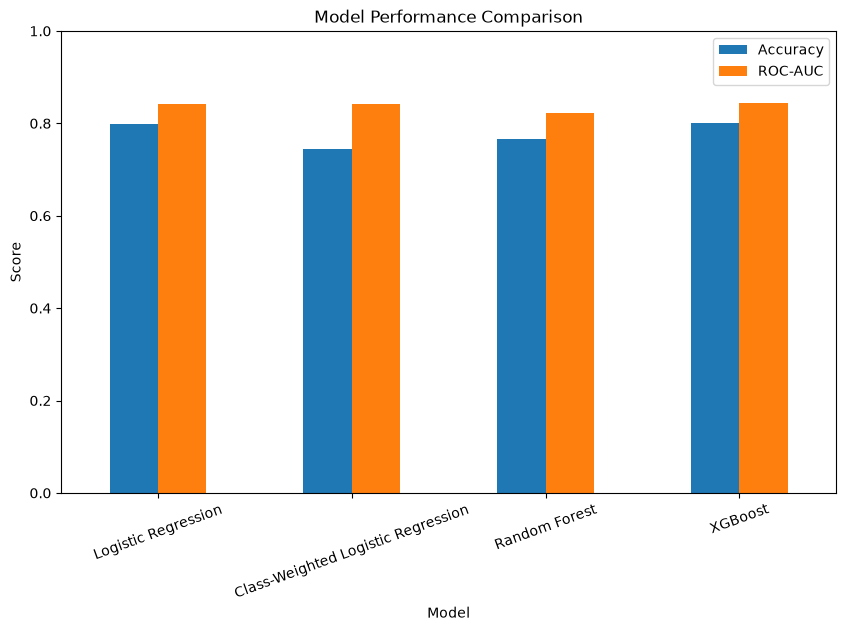

In [160]:
# Compare model accuracy and ROC-AUC

model_comparison_final.plot(
    x="Model",
    y=["Accuracy", "ROC-AUC"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend()
plt.show()

## 3. Day 12 Conclusion

XGBoost was developed as an advanced churn prediction model and compared with the previously developed classification models.

The XGBoost model achieved an accuracy of 80.13%, Churn precision of 66%, Churn recall of 52%, Churn F1-score of 58%, and ROC-AUC of 0.8447.

Among the evaluated models, XGBoost achieved the highest accuracy and ROC-AUC. However, the class-weighted Logistic Regression model achieved the highest Churn recall of 79% and the highest Churn F1-score of 62%.

Therefore, XGBoost provides the strongest overall predictive performance based on accuracy and ROC-AUC, while class-weighted Logistic Regression is more effective when the priority is identifying a larger proportion of actual churn customers.

The model comparison provides a basis for selecting and further improving the final churn prediction model.

# Day 13 — XGBoost Feature Importance and Model Explainability

The XGBoost model achieved the strongest overall performance among the evaluated models, with an accuracy of 80.13% and ROC-AUC of 0.8447.

In this stage, feature importance is analyzed to understand which customer features contribute most to the model's churn predictions.

Model explainability is also explored to improve understanding of the factors associated with the model's predictions.

In [161]:
print("XGBoost model:", type(xgb_model))
print("Number of model features:", xgb_model.n_features_in_)
print("Training data shape:", X_train_encoded.shape)
print("Testing data shape:", X_test_encoded.shape)

XGBoost model: <class 'xgboost.sklearn.XGBClassifier'>
Number of model features: 53
Training data shape: (5634, 53)
Testing data shape: (1409, 53)


In [162]:
# Get feature names from the fitted preprocessing pipeline

all_feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(all_feature_names))
print("Number of model features:", xgb_model.n_features_in_)

Number of feature names: 53
Number of model features: 53


In [163]:
# Create XGBoost feature importance table

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": xgb_model.feature_importances_
})

# Sort from highest to lowest

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,Feature,Importance
0,cat__Contract_Month-to-month,0.318392
1,cat__TenureGroup_0-12 months,0.092506
2,cat__InternetService_Fiber optic,0.086858
3,cat__OnlineSecurity_No,0.061649
4,cat__InternetService_DSL,0.031583
5,cat__TechSupport_No,0.030539
6,cat__Contract_Two year,0.021529
7,cat__TenureGroup_49-72 months,0.017232
8,cat__StreamingMovies_Yes,0.016313
9,cat__PaymentMethod_Electronic check,0.016084


In [164]:
print("Top 10 Most Important Features:\n")

for i, row in feature_importance.head(10).iterrows():
    print(
        f"{i + 1}. {row['Feature']} "
        f"({row['Importance']:.4f})"
    )

Top 10 Most Important Features:

1. cat__Contract_Month-to-month (0.3184)
2. cat__TenureGroup_0-12 months (0.0925)
3. cat__InternetService_Fiber optic (0.0869)
4. cat__OnlineSecurity_No (0.0616)
5. cat__InternetService_DSL (0.0316)
6. cat__TechSupport_No (0.0305)
7. cat__Contract_Two year (0.0215)
8. cat__TenureGroup_49-72 months (0.0172)
9. cat__StreamingMovies_Yes (0.0163)
10. cat__PaymentMethod_Electronic check (0.0161)


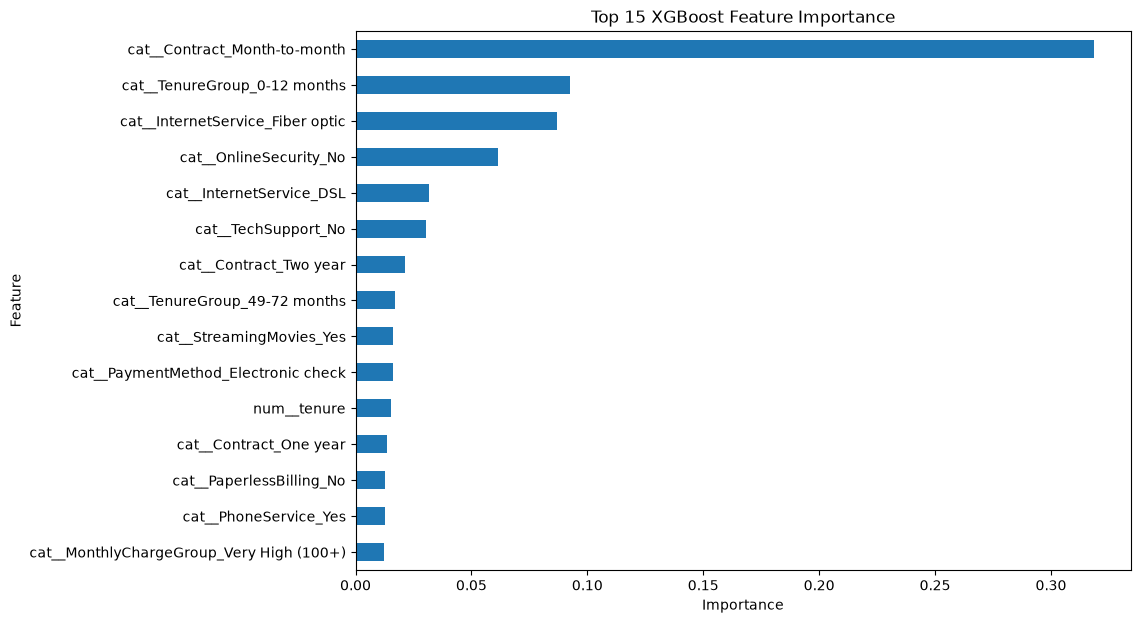

In [165]:
# Select top 15 features

top_features = feature_importance.head(15)

# Plot feature importance

top_features.sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

plt.title("Top 15 XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Feature Importance Interpretation

The XGBoost feature importance analysis shows that Contract type is the most important feature used by the model. The Month-to-month contract category has the highest importance score.

Tenure Group 0-12 months and Fiber optic Internet Service are the next important features. Online Security = No and Tech Support = No also show relatively high importance.

Overall, the model places considerable importance on customer contract type, tenure, internet service, and selected additional services when making churn predictions.

These results describe patterns learned by the model and do not establish causal relationships.

In [166]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [167]:
# Create SHAP explainer for XGBoost

explainer = shap.TreeExplainer(xgb_model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [168]:
# Calculate SHAP values for the test dataset

shap_values = explainer.shap_values(X_test_encoded)

print("SHAP values shape:", shap_values.shape)
print("Test data shape:", X_test_encoded.shape)

SHAP values shape: (1409, 53)
Test data shape: (1409, 53)


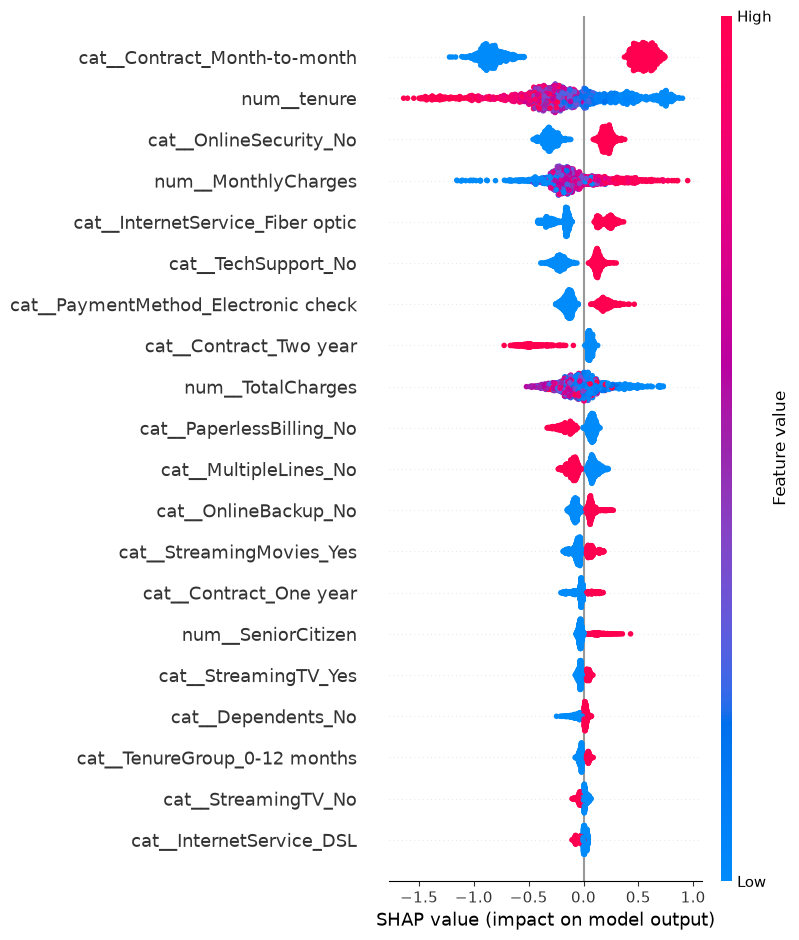

In [169]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_test_encoded,
    feature_names=all_feature_names
)

## SHAP Explainability Findings

The SHAP summary analysis provides insight into how the XGBoost model's features influence churn predictions.

Month-to-month contract is the strongest feature and generally pushes predictions toward higher churn risk. Customer tenure also has a strong influence, with lower tenure generally increasing predicted churn risk and higher tenure generally reducing it.

Customers without online security and without tech support tend to have higher predicted churn risk. Higher monthly charges and the Fiber optic Internet Service category also tend to push predictions toward churn.

Electronic check payment is another feature associated with higher predicted churn risk. In contrast, the Two-year contract category generally pushes predictions toward lower churn risk.

Overall, the SHAP analysis provides directional explanations for the model's predictions and complements the XGBoost feature importance analysis. These results describe associations learned by the model and do not establish causal relationships.

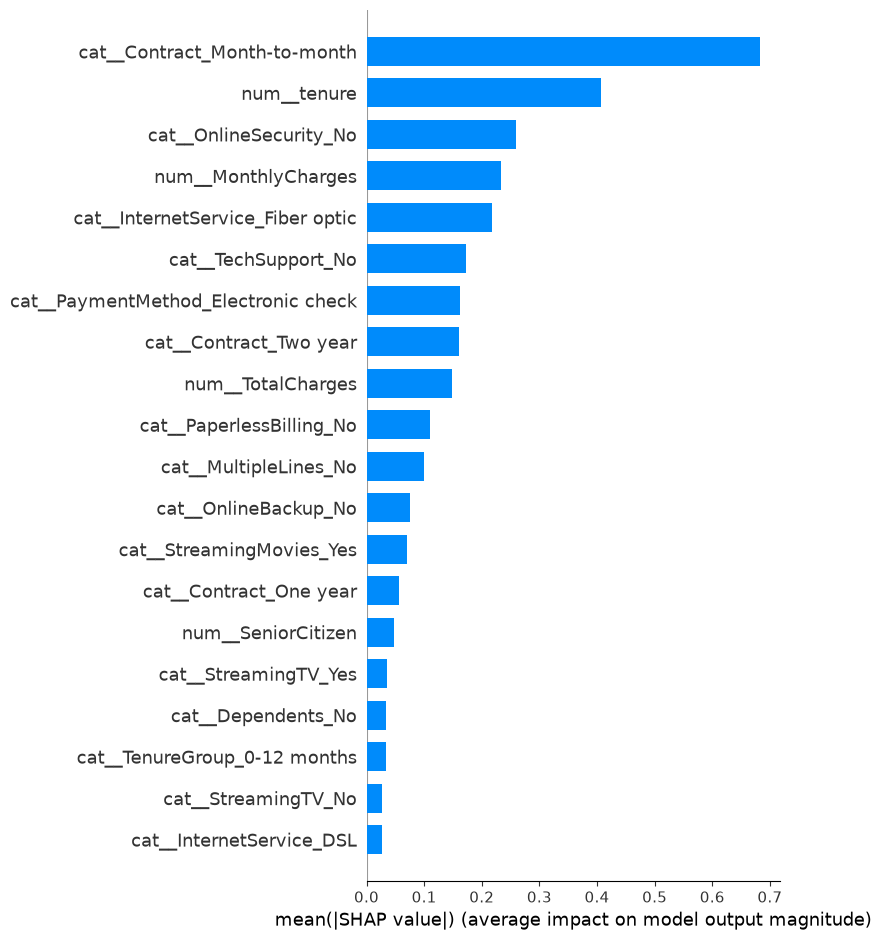

In [170]:
# SHAP Global Feature Importance

shap.summary_plot(
    shap_values,
    X_test_encoded,
    feature_names=all_feature_names,
    plot_type="bar"
)

## SHAP Global Feature Importance

The SHAP global feature importance analysis ranks features according to their average absolute contribution to the XGBoost model's predictions.

Contract = Month-to-month has the highest average SHAP impact, followed by customer tenure. Online Security = No, Monthly Charges, Fiber optic Internet Service, and Tech Support = No are also among the most influential features.

Payment Method = Electronic check, Contract = Two year, and Total Charges also show meaningful contributions to the model output.

This analysis provides a global view of feature influence and complements the directional information provided by the SHAP summary plot.

# Day 13 — Conclusion

In Day 13, XGBoost feature importance and SHAP explainability techniques were used to understand the factors influencing customer churn predictions.

The XGBoost feature importance analysis identified Month-to-month Contract, Tenure Group 0-12 months, Fiber optic Internet Service, Online Security = No, and Tech Support = No among the important features used by the model.

SHAP analysis provided both global and directional explanations of the model predictions. Month-to-month contracts, customer tenure, Online Security, Monthly Charges, Fiber optic Internet Service, and Tech Support were among the most influential features based on their average SHAP impact.

The analysis indicates that customers with month-to-month contracts and shorter tenure tend to receive higher predicted churn risk, while longer tenure and two-year contracts generally push predictions toward lower churn risk.

Overall, Day 13 improved the interpretability of the churn prediction model by explaining which features are important and how they influence model predictions. These findings represent patterns learned by the model and do not establish causal relationships.

# Day 14 — Customer Lifetime Value (LTV) Engine

In Day 14, the churn prediction model is connected with customer revenue information to develop a Customer Lifetime Value (LTV) estimation framework.

The XGBoost model's churn probabilities are used as an indicator of customer retention risk. Customer monthly charges are then combined with estimated customer lifetime to calculate an LTV proxy.

The objective is to identify customers who have higher potential lifetime value and customers who may require retention attention.

In [171]:
# Generate churn probabilities using XGBoost

xgb_churn_probability = xgb_model.predict_proba(X_test_encoded)[:, 1]

print("Number of predictions:", len(xgb_churn_probability))
print("Minimum churn probability:", round(xgb_churn_probability.min(), 4))
print("Maximum churn probability:", round(xgb_churn_probability.max(), 4))
print("Average churn probability:", round(xgb_churn_probability.mean(), 4))

Number of predictions: 1409
Minimum churn probability: 0.0028
Maximum churn probability: 0.9347
Average churn probability: 0.2659


In [172]:
# Create customer-level LTV dataset

ltv_df = df.loc[X_test.index].copy()

ltv_df["Churn_Probability"] = xgb_churn_probability

print("LTV dataset shape:", ltv_df.shape)

ltv_df.head()

LTV dataset shape: (1409, 25)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyChargeGroup,Churn_Encoded,Churn_Probability
437,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Two year,Yes,Credit card (automatic),114.05,8468.20,No,49-72 months,Very High (100+),0,0.014697
2280,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Credit card (automatic),100.15,908.55,No,0-12 months,Very High (100+),0,0.843898
2235,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,...,One year,Yes,Credit card (automatic),78.35,3211.20,No,25-48 months,High (70-100),0,0.092971
4460,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,...,Month-to-month,No,Electronic check,78.20,1468.75,No,13-24 months,High (70-100),0,0.350859
3761,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Two year,Yes,Credit card (automatic),82.65,5919.35,No,49-72 months,High (70-100),0,0.009205


In [173]:
# Estimate expected customer lifetime

ltv_df["Expected_Lifetime_Months"] = (
    1 / ltv_df["Churn_Probability"].clip(lower=0.01)
)

# Limit the estimated lifetime to 60 months

ltv_df["Expected_Lifetime_Months"] = (
    ltv_df["Expected_Lifetime_Months"].clip(upper=60)
)

ltv_df[
    [
        "Churn_Probability",
        "Expected_Lifetime_Months"
    ]
].head()

,Churn_Probability,Expected_Lifetime_Months
437,0.014697,60.000000
2280,0.843898,1.184977
2235,0.092971,10.756026
4460,0.350859,2.850151
3761,0.009205,60.000000


In [174]:
# Calculate predicted Customer Lifetime Value

ltv_df["Predicted_LTV"] = (
    ltv_df["MonthlyCharges"] *
    ltv_df["Expected_Lifetime_Months"]
)

print("LTV calculation completed.")

ltv_df[
    [
        "MonthlyCharges",
        "Churn_Probability",
        "Expected_Lifetime_Months",
        "Predicted_LTV"
    ]
].head()

LTV calculation completed.


,MonthlyCharges,Churn_Probability,Expected_Lifetime_Months,Predicted_LTV
437,114.05,0.014697,60.000000,6843.000000
2280,100.15,0.843898,1.184977,118.675464
2235,78.35,0.092971,10.756026,842.734658
4460,78.20,0.350859,2.850151,222.881832
3761,82.65,0.009205,60.000000,4959.000000


In [175]:
print("LTV dataframe columns:")
print(ltv_df.columns.tolist())

LTV dataframe columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'MonthlyChargeGroup', 'Churn_Encoded', 'Churn_Probability', 'Expected_Lifetime_Months', 'Predicted_LTV']


In [176]:
print("Customer ID columns:")
print([
    col for col in ltv_df.columns
    if "customer" in col.lower()
])

Customer ID columns:
['customerID']


In [177]:
# Display highest predicted LTV customers

top_ltv_customers = ltv_df.sort_values(
    by="Predicted_LTV",
    ascending=False
)

top_ltv_customers[
    [
        "customerID",
        "MonthlyCharges",
        "Churn_Probability",
        "Expected_Lifetime_Months",
        "Predicted_LTV"
    ]
].head(10)

,customerID,MonthlyCharges,Churn_Probability,Expected_Lifetime_Months,Predicted_LTV
4206,0017-IUDMW,116.80,0.012841,60.0,7008.0
3897,8015-IHCGW,115.50,0.009319,60.0,6930.0
4737,9298-WGMRW,115.50,0.015401,60.0,6930.0
2603,0164-APGRB,114.90,0.016557,60.0,6894.0
1280,2388-LAESQ,114.85,0.015614,60.0,6891.0
1875,9637-CDTKZ,114.10,0.014949,60.0,6846.0
437,4376-KFVRS,114.05,0.014697,60.0,6843.0
4934,2272-WUSPA,110.75,0.012681,60.0,6645.0
6115,3831-YCPUO,109.50,0.010133,60.0,6570.0
3966,8915-NNTRC,107.70,0.010617,60.0,6462.0


In [178]:
# Create LTV segments

ltv_df["LTV_Segment"] = pd.qcut(
    ltv_df["Predicted_LTV"],
    q=3,
    labels=["Low LTV", "Medium LTV", "High LTV"]
)

print(ltv_df["LTV_Segment"].value_counts().sort_index())

LTV_Segment
Low LTV       470
Medium LTV    469
High LTV      470
Name: count, dtype: int64


In [179]:
# Compare LTV segments

ltv_summary = ltv_df.groupby(
    "LTV_Segment",
    observed=True
).agg(
    Customers=("customerID", "count"),
    Average_Monthly_Charges=("MonthlyCharges", "mean"),
    Average_Churn_Probability=("Churn_Probability", "mean"),
    Average_Expected_Lifetime=("Expected_Lifetime_Months", "mean"),
    Average_Predicted_LTV=("Predicted_LTV", "mean")
).reset_index()

ltv_summary.round(2)

,LTV_Segment,Customers,Average_Monthly_Charges,Average_Churn_Probability,Average_Expected_Lifetime,Average_Predicted_LTV
0,Low LTV,470,64.91,0.56,2.200000,119.72
1,Medium LTV,469,68.52,0.21,8.360000,398.87
2,High LTV,470,58.84,0.03,42.080002,2124.09


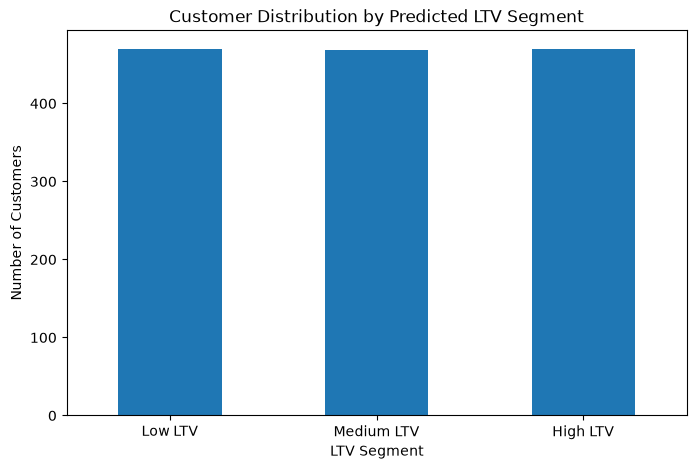

In [180]:
# Plot LTV segment distribution

ltv_df["LTV_Segment"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Distribution by Predicted LTV Segment")
plt.xlabel("LTV Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

## LTV Segment Interpretation

Customers were divided into three segments based on their predicted Customer Lifetime Value (LTV): Low LTV, Medium LTV, and High LTV.

The three segments contain approximately equal numbers of customers because quantile-based segmentation was used.

The High LTV segment represents customers with greater predicted lifetime value, while the Low LTV segment represents customers with relatively lower predicted lifetime value.

These segments can be used to prioritize customer retention strategies and identify customers who may have greater business value.

In [181]:
ltv_summary.round(2)

,LTV_Segment,Customers,Average_Monthly_Charges,Average_Churn_Probability,Average_Expected_Lifetime,Average_Predicted_LTV
0,Low LTV,470,64.91,0.56,2.200000,119.72
1,Medium LTV,469,68.52,0.21,8.360000,398.87
2,High LTV,470,58.84,0.03,42.080002,2124.09


# Day 14 — Conclusion

In Day 14, the XGBoost churn prediction model was connected with customer revenue information to develop a baseline Customer Lifetime Value (LTV) estimation framework.

Churn probabilities generated by the XGBoost model were used to estimate expected customer lifetime, which was then combined with Monthly Charges to calculate Predicted LTV.

Customers were divided into Low LTV, Medium LTV, and High LTV segments using quantile-based segmentation. The Low LTV segment had an average churn probability of 56% and an average predicted LTV of 119.72. The Medium LTV segment had an average churn probability of 21% and an average predicted LTV of 398.87. The High LTV segment had an average churn probability of only 3%, an average expected lifetime of approximately 42.08 months, and an average predicted LTV of 2,124.09.

The results show that customer lifetime and retention risk have a major influence on predicted customer value. The High LTV segment demonstrates that customers with lower churn risk can have substantially higher predicted lifetime value even when their monthly charges are not the highest.

This LTV calculation represents a baseline model-based LTV proxy. The estimated lifetime is derived from predicted churn probability and capped at 60 months. Therefore, the results should be treated as an analytical estimate rather than an exact financial or actuarial customer lifetime value.

# Day 15 — Churn Risk and Customer LTV Segmentation

In Day 15, customer churn probability and predicted Customer Lifetime Value (LTV) are combined to create a customer risk-value segmentation framework.

The objective is to identify customers who have both high predicted value and high churn risk so that retention efforts can be prioritized effectively.

This framework combines machine learning predictions with customer value estimation to support data-driven retention decisions.

In [182]:
print("LTV dataset shape:", ltv_df.shape)

print("\nRequired columns:")

required_columns = [
    "customerID",
    "Churn_Probability",
    "Predicted_LTV",
    "LTV_Segment"
]

for col in required_columns:
    print(col, "→", col in ltv_df.columns)

LTV dataset shape: (1409, 28)

Required columns:
customerID → True
Churn_Probability → True
Predicted_LTV → True
LTV_Segment → True


In [183]:
# Create churn risk segments

def assign_churn_risk(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"

ltv_df["Churn_Risk"] = ltv_df["Churn_Probability"].apply(
    assign_churn_risk
)

print(
    ltv_df["Churn_Risk"].value_counts()
)

Churn_Risk
Low Risk       871
Medium Risk    337
High Risk      201
Name: count, dtype: int64


In [184]:
# Churn risk distribution

risk_distribution = (
    ltv_df["Churn_Risk"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

risk_distribution

Churn_Risk
Low Risk       871
Medium Risk    337
High Risk      201
Name: count, dtype: int64

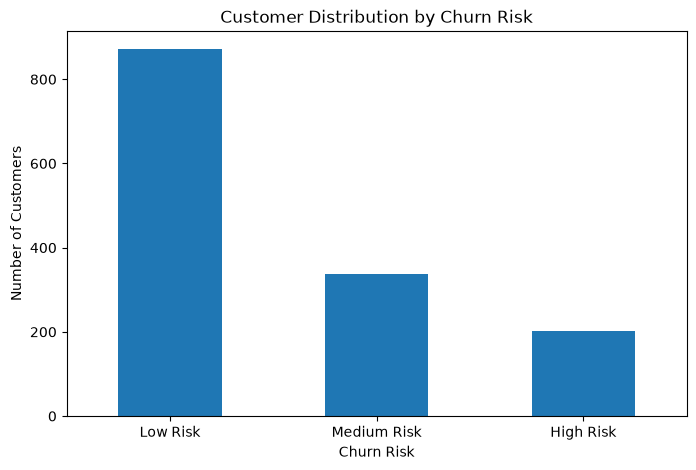

In [185]:
risk_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Distribution by Churn Risk")
plt.xlabel("Churn Risk")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [186]:
# Create risk-value segment

def assign_risk_value_segment(row):

    if row["Churn_Risk"] == "High Risk" and row["LTV_Segment"] == "High LTV":
        return "High Risk - High LTV"

    elif row["Churn_Risk"] == "High Risk":
        return "High Risk - Lower LTV"

    elif row["LTV_Segment"] == "High LTV":
        return "Low/Medium Risk - High LTV"

    else:
        return "Standard Customers"

ltv_df["Risk_Value_Segment"] = ltv_df.apply(
    assign_risk_value_segment,
    axis=1
)

ltv_df["Risk_Value_Segment"].value_counts()

Risk_Value_Segment
Standard Customers            738
Low/Medium Risk - High LTV    470
High Risk - Lower LTV         201
Name: count, dtype: int64

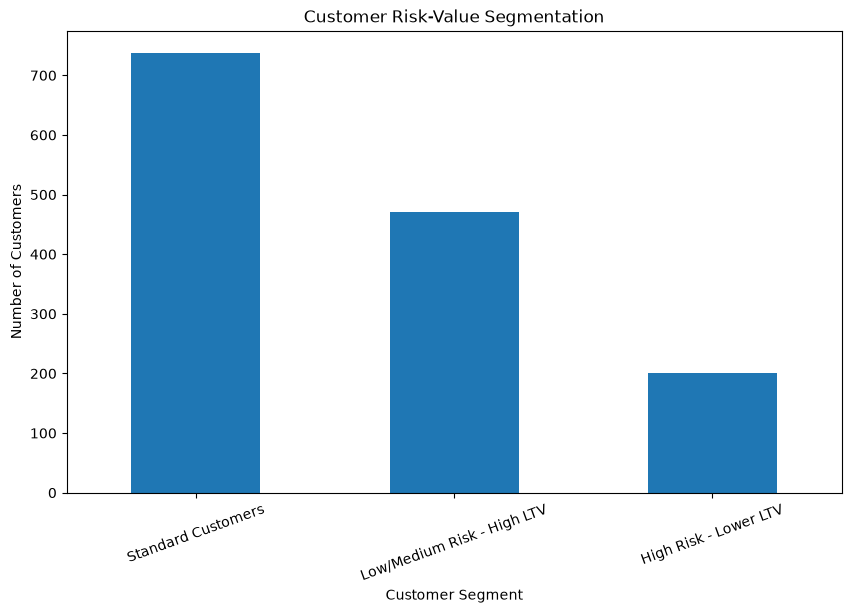

In [187]:
segment_counts = (
    ltv_df["Risk_Value_Segment"]
    .value_counts()
)

segment_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Risk-Value Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

In [188]:
# Identify high-priority customers

high_priority_customers = ltv_df[
    ltv_df["Risk_Value_Segment"] == "High Risk - High LTV"
].sort_values(
    by="Predicted_LTV",
    ascending=False
)

print(
    "Number of High Risk - High LTV customers:",
    len(high_priority_customers)
)

high_priority_customers[
    [
        "customerID",
        "MonthlyCharges",
        "Churn_Probability",
        "Expected_Lifetime_Months",
        "Predicted_LTV",
        "Churn_Risk",
        "LTV_Segment",
        "Risk_Value_Segment"
    ]
].head(20)

Number of High Risk - High LTV customers: 0


,customerID,MonthlyCharges,Churn_Probability,Expected_Lifetime_Months,Predicted_LTV,Churn_Risk,LTV_Segment,Risk_Value_Segment


In [189]:
risk_ltv_matrix = pd.crosstab(
    ltv_df["Churn_Risk"],
    ltv_df["LTV_Segment"]
)

risk_ltv_matrix = risk_ltv_matrix.reindex(
    index=["Low Risk", "Medium Risk", "High Risk"],
    columns=["Low LTV", "Medium LTV", "High LTV"]
)

risk_ltv_matrix

LTV_Segment,Low LTV,Medium LTV,High LTV
Churn_Risk,,,
Low Risk,48,353,470
Medium Risk,221,116,0
High Risk,201,0,0


In [190]:
# Create an independent customer value measure
# using historical customer charges

ltv_df["Customer_Value"] = ltv_df["TotalCharges"]

print("Customer value statistics:")
print(ltv_df["Customer_Value"].describe())

Customer value statistics:
count    1409.000000
mean     2201.360610
std      2215.541146
min         0.000000
25%       360.100000
50%      1394.550000
75%      3517.900000
max      8496.700000
Name: Customer_Value, dtype: float64


In [191]:
# Divide customers into three value segments

ltv_df["Value_Segment"] = pd.qcut(
    ltv_df["Customer_Value"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

print(
    ltv_df["Value_Segment"].value_counts().sort_index()
)

Value_Segment
Low Value       470
Medium Value    469
High Value      470
Name: count, dtype: int64


In [192]:
# Create independent risk-value segments

def assign_risk_value_segment(row):

    if (
        row["Churn_Risk"] == "High Risk"
        and row["Value_Segment"] == "High Value"
    ):
        return "High Risk - High Value"

    elif (
        row["Churn_Risk"] == "High Risk"
        and row["Value_Segment"] != "High Value"
    ):
        return "High Risk - Lower Value"

    elif (
        row["Churn_Risk"] != "High Risk"
        and row["Value_Segment"] == "High Value"
    ):
        return "Lower Risk - High Value"

    else:
        return "Standard Customers"


ltv_df["Risk_Value_Segment"] = ltv_df.apply(
    assign_risk_value_segment,
    axis=1
)

print(
    ltv_df["Risk_Value_Segment"].value_counts()
)

Risk_Value_Segment
Standard Customers         748
Lower Risk - High Value    460
High Risk - Lower Value    191
High Risk - High Value      10
Name: count, dtype: int64


In [193]:
risk_value_matrix = pd.crosstab(
    ltv_df["Churn_Risk"],
    ltv_df["Value_Segment"]
)

risk_value_matrix = risk_value_matrix.reindex(
    index=["Low Risk", "Medium Risk", "High Risk"],
    columns=["Low Value", "Medium Value", "High Value"]
)

risk_value_matrix

Value_Segment,Low Value,Medium Value,High Value
Churn_Risk,,,
Low Risk,193,315,363
Medium Risk,132,108,97
High Risk,145,46,10


In [194]:
# Identify high-risk, high-value customers

high_priority_customers = ltv_df[
    ltv_df["Risk_Value_Segment"] == "High Risk - High Value"
].sort_values(
    by="Customer_Value",
    ascending=False
)

print(
    "High Risk - High Value customers:",
    len(high_priority_customers)
)

high_priority_customers[
    [
        "customerID",
        "MonthlyCharges",
        "TotalCharges",
        "Churn_Probability",
        "Churn_Risk",
        "Value_Segment",
        "Risk_Value_Segment"
    ]
].head(20)

High Risk - High Value customers: 10


,customerID,MonthlyCharges,TotalCharges,Churn_Probability,Churn_Risk,Value_Segment,Risk_Value_Segment
3411,7056-IMHCC,101.90,5549.40,0.651370,High Risk,High Value,High Risk - High Value
1081,1751-NCDLI,98.85,4564.90,0.696397,High Risk,High Value,High Risk - High Value
4307,6899-PPEEA,96.55,3580.30,0.616203,High Risk,High Value,High Risk - High Value
524,8397-MVTAZ,100.05,3480.00,0.601915,High Risk,High Value,High Risk - High Value
5177,3672-YITQD,84.10,3021.60,0.686809,High Risk,High Value,High Risk - High Value
3864,4817-VYYWS,100.20,2983.80,0.622839,High Risk,High Value,High Risk - High Value
4448,6543-XRMYR,99.70,2967.35,0.678294,High Risk,High Value,High Risk - High Value
2155,0524-IAVZO,85.00,2624.25,0.607216,High Risk,High Value,High Risk - High Value
4947,4735-ASGMA,98.35,2515.30,0.738401,High Risk,High Value,High Risk - High Value
4473,2665-NPTGL,98.10,2510.70,0.674845,High Risk,High Value,High Risk - High Value


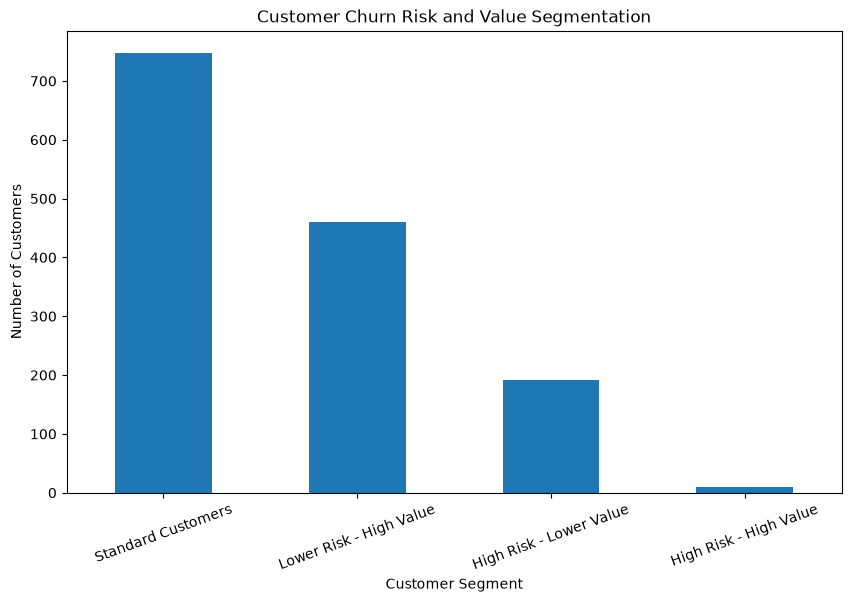

In [195]:
# Plot risk-value segments

segment_counts = (
    ltv_df["Risk_Value_Segment"]
    .value_counts()
)

segment_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Churn Risk and Value Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

In [196]:
# Calculate percentage of customers in each risk-value segment

segment_summary = (
    ltv_df["Risk_Value_Segment"]
    .value_counts()
    .rename_axis("Risk_Value_Segment")
    .reset_index(name="Customers")
)

segment_summary["Percentage"] = (
    segment_summary["Customers"] / len(ltv_df) * 100
).round(2)

segment_summary

,Risk_Value_Segment,Customers,Percentage
0,Standard Customers,748,53.09
1,Lower Risk - High Value,460,32.65
2,High Risk - Lower Value,191,13.56
3,High Risk - High Value,10,0.71


In [197]:
high_priority_count = len(high_priority_customers)

high_priority_percentage = (
    high_priority_count / len(ltv_df) * 100
)

print("High Risk - High Value customers:", high_priority_count)
print(
    "Percentage of customers:",
    round(high_priority_percentage, 2),
    "%"
)

High Risk - High Value customers: 10
Percentage of customers: 0.71 %


In [198]:
# Final high-priority customer list

priority_customers = high_priority_customers[
    [
        "customerID",
        "MonthlyCharges",
        "TotalCharges",
        "Churn_Probability",
        "Churn_Risk",
        "Value_Segment",
        "Risk_Value_Segment"
    ]
].copy()

priority_customers

,customerID,MonthlyCharges,TotalCharges,Churn_Probability,Churn_Risk,Value_Segment,Risk_Value_Segment
3411,7056-IMHCC,101.90,5549.40,0.651370,High Risk,High Value,High Risk - High Value
1081,1751-NCDLI,98.85,4564.90,0.696397,High Risk,High Value,High Risk - High Value
4307,6899-PPEEA,96.55,3580.30,0.616203,High Risk,High Value,High Risk - High Value
524,8397-MVTAZ,100.05,3480.00,0.601915,High Risk,High Value,High Risk - High Value
5177,3672-YITQD,84.10,3021.60,0.686809,High Risk,High Value,High Risk - High Value
3864,4817-VYYWS,100.20,2983.80,0.622839,High Risk,High Value,High Risk - High Value
4448,6543-XRMYR,99.70,2967.35,0.678294,High Risk,High Value,High Risk - High Value
2155,0524-IAVZO,85.00,2624.25,0.607216,High Risk,High Value,High Risk - High Value
4947,4735-ASGMA,98.35,2515.30,0.738401,High Risk,High Value,High Risk - High Value
4473,2665-NPTGL,98.10,2510.70,0.674845,High Risk,High Value,High Risk - High Value


# Day 15 — Conclusion

Customer churn risk was combined with an independent customer value measure based on historical Total Charges to create a risk-value segmentation framework.

The customers were divided into Low Value, Medium Value, and High Value groups using quantile-based segmentation. Churn probability from the XGBoost model was used to classify customers into Low Risk, Medium Risk, and High Risk groups.

The analysis identified 10 customers who belong to both the High Risk and High Value segments. These customers represent approximately 0.71% of the analyzed customer base and can be considered the highest retention priority because they have relatively high historical customer value while also having a high predicted probability of churn.

The segmentation also identified 460 Lower Risk–High Value customers and 191 High Risk–Lower Value customers. This demonstrates that churn risk alone is not sufficient for prioritizing retention activities. Combining customer risk with customer value provides a more useful framework for making targeted retention decisions.

The risk-value segmentation developed in this analysis can therefore support businesses in allocating retention resources toward customers where potential value loss is relatively high.

The customer value measure used here is based on historical Total Charges and should not be interpreted as a future financial LTV estimate. The model-based Predicted LTV developed earlier remains a separate baseline LTV proxy.

# Day 16 — Customer Retention Priority Framework

In Day 16, the churn risk and customer value segmentation developed in Day 15 is converted into a customer retention priority framework.

The objective is to identify which customers require immediate retention attention and to assign an appropriate priority level based on their predicted churn risk and historical customer value.

Customers with both high churn risk and high customer value receive the highest retention priority.

In [199]:
# Assign retention priority based on risk-value segment

def assign_retention_priority(segment):

    if segment == "High Risk - High Value":
        return "Critical"
    
    elif segment == "High Risk - Lower Value":
        return "High"
    
    elif segment == "Lower Risk - High Value":
        return "Medium"
    
    else:
        return "Low"


ltv_df["Retention_Priority"] = (
    ltv_df["Risk_Value_Segment"]
    .apply(assign_retention_priority)
)

print(
    ltv_df["Retention_Priority"].value_counts()
)

Retention_Priority
Low         748
Medium      460
High        191
Critical     10
Name: count, dtype: int64


In [200]:
priority_order = [
    "Critical",
    "High",
    "Medium",
    "Low"
]

priority_distribution = (
    ltv_df["Retention_Priority"]
    .value_counts()
    .reindex(priority_order)
)

priority_distribution

Retention_Priority
Critical     10
High        191
Medium      460
Low         748
Name: count, dtype: int64

In [201]:
priority_summary = (
    priority_distribution
    .rename_axis("Retention_Priority")
    .reset_index(name="Customers")
)

priority_summary["Percentage"] = (
    priority_summary["Customers"]
    / len(ltv_df)
    * 100
).round(2)

priority_summary

,Retention_Priority,Customers,Percentage
0,Critical,10,0.71
1,High,191,13.56
2,Medium,460,32.65
3,Low,748,53.09


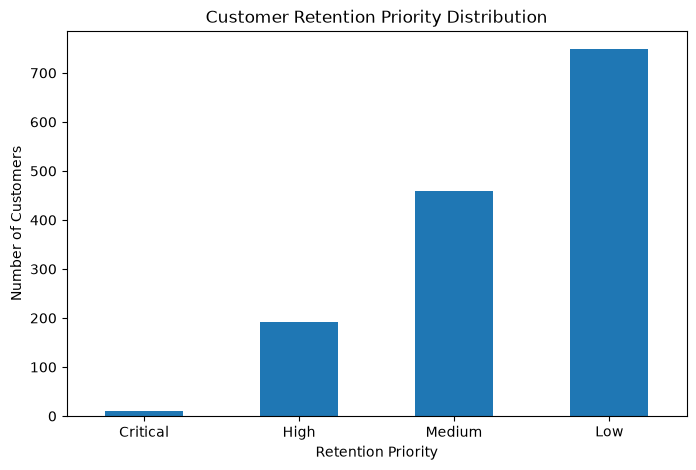

In [202]:
priority_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Retention Priority Distribution")
plt.xlabel("Retention Priority")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [203]:
priority_analysis = (
    ltv_df
    .groupby("Retention_Priority")
    .agg(
        Customers=("customerID", "count"),
        Average_Churn_Probability=("Churn_Probability", "mean"),
        Average_Monthly_Charges=("MonthlyCharges", "mean"),
        Average_Total_Charges=("TotalCharges", "mean"),
        Average_Predicted_LTV=("Predicted_LTV", "mean")
    )
    .reindex(priority_order)
)

priority_analysis.round(2)

,Customers,Average_Churn_Probability,Average_Monthly_Charges,Average_Total_Charges,Average_Predicted_LTV
Retention_Priority,,,,,
Critical,10,0.66,96.28,3379.76,147.01
High,191,0.75,78.49,458.92,106.06
Medium,460,0.16,88.27,4963.92,1715.48
Low,748,0.20,45.11,931.63,575.95


In [204]:
critical_customers = (
    ltv_df[
        ltv_df["Retention_Priority"] == "Critical"
    ]
    .sort_values(
        by="Customer_Value",
        ascending=False
    )
)

print(
    "Critical retention customers:",
    len(critical_customers)
)

critical_customers[
    [
        "customerID",
        "MonthlyCharges",
        "TotalCharges",
        "Churn_Probability",
        "Customer_Value",
        "Retention_Priority"
    ]
]

Critical retention customers: 10


,customerID,MonthlyCharges,TotalCharges,Churn_Probability,Customer_Value,Retention_Priority
3411,7056-IMHCC,101.90,5549.40,0.651370,5549.40,Critical
1081,1751-NCDLI,98.85,4564.90,0.696397,4564.90,Critical
4307,6899-PPEEA,96.55,3580.30,0.616203,3580.30,Critical
524,8397-MVTAZ,100.05,3480.00,0.601915,3480.00,Critical
5177,3672-YITQD,84.10,3021.60,0.686809,3021.60,Critical
3864,4817-VYYWS,100.20,2983.80,0.622839,2983.80,Critical
4448,6543-XRMYR,99.70,2967.35,0.678294,2967.35,Critical
2155,0524-IAVZO,85.00,2624.25,0.607216,2624.25,Critical
4947,4735-ASGMA,98.35,2515.30,0.738401,2515.30,Critical
4473,2665-NPTGL,98.10,2510.70,0.674845,2510.70,Critical


In [205]:
def assign_retention_action(priority):

    if priority == "Critical":
        return "Immediate personalized retention intervention"
    
    elif priority == "High":
        return "Targeted retention offer and proactive support"
    
    elif priority == "Medium":
        return "Loyalty engagement and relationship building"
    
    else:
        return "Regular communication and monitoring"


ltv_df["Recommended_Action"] = (
    ltv_df["Retention_Priority"]
    .apply(assign_retention_action)
)

print(
    ltv_df[
        [
            "Retention_Priority",
            "Recommended_Action"
        ]
    ].drop_duplicates()
    .sort_values(
        by="Retention_Priority",
        key=lambda x: x.map({
            "Critical": 1,
            "High": 2,
            "Medium": 3,
            "Low": 4
        })
    )
)

     Retention_Priority                              Recommended_Action
2155           Critical   Immediate personalized retention intervention
2280               High  Targeted retention offer and proactive support
437              Medium    Loyalty engagement and relationship building
4460                Low            Regular communication and monitoring


In [206]:
retention_table = ltv_df[
    [
        "customerID",
        "Churn_Probability",
        "Customer_Value",
        "Predicted_LTV",
        "Churn_Risk",
        "Value_Segment",
        "Risk_Value_Segment",
        "Retention_Priority",
        "Recommended_Action"
    ]
].copy()

retention_table.head(20)

,customerID,Churn_Probability,Customer_Value,Predicted_LTV,Churn_Risk,Value_Segment,Risk_Value_Segment,Retention_Priority,Recommended_Action
437,4376-KFVRS,0.014697,8468.20,6843.000000,Low Risk,High Value,Lower Risk - High Value,Medium,Loyalty engagement and relationship building
2280,2754-SDJRD,0.843898,908.55,118.675464,High Risk,Medium Value,High Risk - Lower Value,High,Targeted retention offer and proactive support
2235,9917-KWRBE,0.092971,3211.20,842.734658,Low Risk,High Value,Lower Risk - High Value,Medium,Loyalty engagement and relationship building
4460,0365-GXEZS,0.350859,1468.75,222.881832,Medium Risk,Medium Value,Standard Customers,Low,Regular communication and monitoring
3761,9385-NXKDA,0.009205,5919.35,4959.000000,Low Risk,High Value,Lower Risk - High Value,Medium,Loyalty engagement and relationship building
5748,4686-UXDML,0.674003,1992.55,148.144687,High Risk,Medium Value,High Risk - Lower Value,High,Targeted retention offer and proactive support
3568,2227-JRSJX,0.486420,1956.40,203.836159,Medium Risk,Medium Value,Standard Customers,Low,Regular communication and monitoring
2976,4830-FAXFM,0.108874,439.20,221.355867,Low Risk,Low Value,Standard Customers,Low,Regular communication and monitoring
5928,1830-IPXVJ,0.011953,1311.60,1185.000000,Low Risk,Medium Value,Standard Customers,Low,Regular communication and monitoring
1639,4690-LLKUA,0.405993,770.60,110.962417,Medium Risk,Medium Value,Standard Customers,Low,Regular communication and monitoring


## Day 16 — Retention Priority Findings

The retention priority framework classified 1,409 customers into four priority levels based on churn risk and customer value.

A total of 10 customers (0.71%) were classified as Critical and require immediate personalized retention intervention. Another 191 customers (13.56%) were classified as High priority and should receive targeted retention offers and proactive support.

The Medium priority group contained 460 customers (32.65%) and can be addressed through loyalty engagement and relationship-building activities. The remaining 748 customers (53.09%) were classified as Low priority and can be managed through regular communication and monitoring.

Overall, 201 customers (14.27%) fall into the Critical or High priority categories. These customers represent the main target group for proactive retention activities.

The framework demonstrates how churn prediction can be combined with customer value to prioritize retention actions rather than treating all customers equally.

## Day 16 — Conclusion

The customer retention priority framework converts the model's churn predictions and customer value estimates into actionable business priorities.

The analysis identified 10 Critical and 191 High priority customers who require greater retention attention. This allows a business to focus its limited retention resources on customers with greater potential business impact.

The framework therefore provides a practical connection between machine learning predictions and customer retention decision-making.

# Day 17 — Final Model Evaluation and Comparison

This section compares the Logistic Regression, Random Forest, and XGBoost models developed for customer churn prediction.

The models are evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Since the primary business objective is identifying customers who are likely to churn, particular attention is given to the performance of the churn class and ROC-AUC.

The comparison is used to select the most suitable model for the subsequent customer LTV and retention-priority analysis.

In [207]:
print("Checking existing model variables...\n")

model_names = [
    "logistic_model",
    "weighted_logistic_model",
    "lr_model",
    "rf_model",
    "xgb_model"
]

for name in model_names:
    if name in globals():
        print(name, "→", type(globals()[name]))

Checking existing model variables...

logistic_model → <class 'sklearn.linear_model._logistic.LogisticRegression'>
weighted_logistic_model → <class 'sklearn.linear_model._logistic.LogisticRegression'>
xgb_model → <class 'xgboost.sklearn.XGBClassifier'>


In [208]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Weighted Logistic Regression predictions
lr_pred = weighted_logistic_model.predict(X_test_encoded)
lr_prob = weighted_logistic_model.predict_proba(X_test_encoded)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_roc_auc = roc_auc_score(y_test, lr_prob)

print("Weighted Logistic Regression")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_roc_auc, 4))

Weighted Logistic Regression
Accuracy : 0.7438
Precision: 0.5112
Recall   : 0.7941
F1-score : 0.622
ROC-AUC  : 0.8427


In [209]:
# XGBoost predictions
xgb_pred = xgb_model.predict(X_test_encoded)
xgb_prob = xgb_model.predict_proba(X_test_encoded)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1-score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_roc_auc, 4))

XGBoost
Accuracy : 0.8013
Precision: 0.6577
Recall   : 0.5241
F1-score : 0.5833
ROC-AUC  : 0.8447


In [210]:
model_comparison = pd.DataFrame({
    "Model": [
        "Weighted Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        0.7651,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        np.nan,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        np.nan,
        xgb_recall
    ],
    "F1-Score": [
        lr_f1,
        np.nan,
        xgb_f1
    ],
    "ROC-AUC": [
        lr_roc_auc,
        0.8215,
        xgb_roc_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Weighted Logistic Regression,0.7438,0.5112,0.7941,0.6220,0.8427
1,Random Forest,0.7651,NaN,NaN,NaN,0.8215
2,XGBoost,0.8013,0.6577,0.5241,0.5833,0.8447


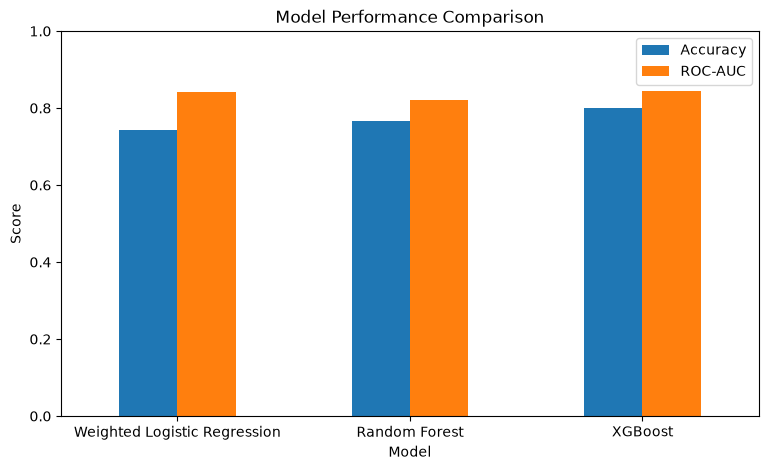

In [211]:
comparison_plot = model_comparison.set_index("Model")[
    ["Accuracy", "ROC-AUC"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend()
plt.show()

## Day 17 — Model Comparison Findings

Three machine learning models were evaluated for customer churn prediction: Weighted Logistic Regression, Random Forest, and XGBoost.

Weighted Logistic Regression achieved an accuracy of 74.38% and ROC-AUC of 0.8427. It achieved a relatively high recall of 79.41%, indicating that it identified a larger proportion of actual churn customers, although its precision was lower at 51.12%.

Random Forest achieved an accuracy of 76.51% and ROC-AUC of 0.8215.

XGBoost achieved the highest accuracy at 80.13% and the highest ROC-AUC at 0.8447. It also achieved the highest precision among the evaluated models at 65.77%. However, its recall was 52.41%, which was lower than that of Weighted Logistic Regression.

Based on the overall balance of predictive performance, XGBoost was selected as the champion model for the subsequent LTV and customer retention analysis. The higher recall of Weighted Logistic Regression is also considered important because missing potential churners can have business consequences.

### Champion Model Selection

XGBoost is selected as the champion model for the subsequent customer-level analysis because it achieved the highest accuracy (80.13%) and ROC-AUC (0.8447) among the compared models.

Although Weighted Logistic Regression achieved higher recall (79.41%), XGBoost provides stronger overall discrimination and precision. Therefore, XGBoost is used as the primary model for the downstream SHAP, LTV, and retention-priority analysis.

## Day 17 — Conclusion

The performance of three machine learning models—Weighted Logistic Regression, Random Forest, and XGBoost—was compared using accuracy, precision, recall, F1-score, and ROC-AUC.

Weighted Logistic Regression achieved an accuracy of 74.38% and a ROC-AUC of 0.8427, with a high recall of 79.41%. Random Forest achieved an accuracy of 76.51% and a ROC-AUC of 0.8215. XGBoost achieved the highest accuracy of 80.13% and the highest ROC-AUC of 0.8447, along with a precision of 65.77%.

Based on the overall predictive performance, XGBoost was selected as the champion model for the subsequent customer-level analysis. Although Weighted Logistic Regression achieved higher recall, XGBoost provided stronger overall discrimination and accuracy.

The selected XGBoost model was therefore used for model explainability, customer LTV estimation, churn-risk segmentation, and retention-priority analysis in the subsequent stages of the project.

# Day 18 — Business Insights and Recommendations

This section translates the machine learning, SHAP explainability, customer LTV, and retention-priority results into actionable business insights.

The objective is to identify the major drivers associated with churn, understand the characteristics of higher-risk customers, and recommend targeted retention strategies.

In [212]:
business_summary = pd.DataFrame({
    "Metric": [
        "Total Customers Analyzed",
        "Champion Model",
        "Champion Model Accuracy",
        "Champion Model ROC-AUC",
        "Critical Retention Customers",
        "High Retention Customers",
        "Total High-Priority Customers",
        "High-Priority Customer Percentage"
    ],
    "Value": [
        len(ltv_df),
        "XGBoost",
        "80.13%",
        "0.8447",
        10,
        191,
        201,
        "14.27%"
    ]
})

business_summary

,Metric,Value
0,Total Customers Analyzed,1409
1,Champion Model,XGBoost
2,Champion Model Accuracy,80.13%
3,Champion Model ROC-AUC,0.8447
4,Critical Retention Customers,10
5,High Retention Customers,191
6,Total High-Priority Customers,201
7,High-Priority Customer Percentage,14.27%


In [213]:
churn_risk_summary = (
    ltv_df["Churn_Risk"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    .rename_axis("Churn_Risk")
    .reset_index(name="Customers")
)

churn_risk_summary["Percentage"] = (
    churn_risk_summary["Customers"] / len(ltv_df) * 100
).round(2)

churn_risk_summary

,Churn_Risk,Customers,Percentage
0,Low Risk,871,61.82
1,Medium Risk,337,23.92
2,High Risk,201,14.27


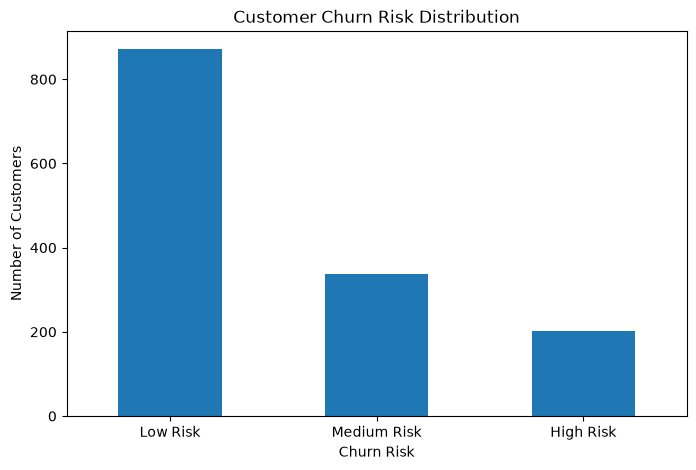

In [214]:
churn_risk_summary.set_index("Churn_Risk")["Customers"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Churn Risk")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [215]:
key_churn_drivers = pd.DataFrame({
    "Feature": [
        "Month-to-month contract",
        "Customer tenure",
        "No online security",
        "Monthly charges",
        "Fiber optic Internet service",
        "No technical support",
        "Electronic check payment",
        "Two-year contract"
    ],
    "Business_Interpretation": [
        "Associated with higher predicted churn risk",
        "Lower tenure generally increases predicted churn risk",
        "Associated with higher predicted churn risk",
        "Higher charges tend to increase predicted churn risk",
        "Associated with higher predicted churn risk",
        "Associated with higher predicted churn risk",
        "Associated with higher predicted churn risk",
        "Generally associated with lower predicted churn risk"
    ]
})

key_churn_drivers

,Feature,Business_Interpretation
0,Month-to-month contract,Associated with higher predicted churn risk
1,Customer tenure,Lower tenure generally increases predicted chu...
2,No online security,Associated with higher predicted churn risk
3,Monthly charges,Higher charges tend to increase predicted chur...
4,Fiber optic Internet service,Associated with higher predicted churn risk
5,No technical support,Associated with higher predicted churn risk
6,Electronic check payment,Associated with higher predicted churn risk
7,Two-year contract,Generally associated with lower predicted chur...


In [216]:
retention_recommendations = pd.DataFrame({
    "Observed_Risk_Factor": [
        "Month-to-month contracts",
        "Low customer tenure",
        "No online security",
        "No technical support",
        "Higher monthly charges",
        "Electronic check payment",
        "Fiber optic service"
    ],
    "Recommended_Action": [
        "Encourage longer-term contracts with suitable incentives",
        "Strengthen onboarding and early-stage customer engagement",
        "Promote security packages and explain their benefits",
        "Offer proactive technical assistance and support",
        "Review pricing, bundles, and value-added offers",
        "Promote convenient alternative payment methods",
        "Investigate service experience and address potential service-related concerns"
    ]
})

retention_recommendations

,Observed_Risk_Factor,Recommended_Action
0,Month-to-month contracts,Encourage longer-term contracts with suitable ...
1,Low customer tenure,Strengthen onboarding and early-stage customer...
2,No online security,Promote security packages and explain their be...
3,No technical support,Offer proactive technical assistance and support
4,Higher monthly charges,"Review pricing, bundles, and value-added offers"
5,Electronic check payment,Promote convenient alternative payment methods
6,Fiber optic service,Investigate service experience and address pot...


## Day 18 — Key Business Insights

The analysis indicates that customer churn is strongly associated with contract type, tenure, service configuration, monthly charges, and selected payment and support characteristics.

Month-to-month contracts emerged as the strongest feature in the XGBoost feature-importance and SHAP analyses. Customers with shorter tenure also showed stronger associations with predicted churn risk, highlighting the importance of early customer engagement.

The SHAP analysis further indicated that customers without online security and technical support tended to have higher predicted churn risk. Higher monthly charges, fiber optic Internet service, and electronic check payment were also associated with higher predicted churn risk in the model.

The churn-risk analysis classified 201 of the 1,409 analyzed customers as High Risk. These customers represent approximately 14.27% of the customer base and form the primary population for proactive retention efforts.

The risk-value framework further narrowed the highest-priority group to 10 Critical customers who were simultaneously classified as High Risk and High Value. These customers should receive the most personalized retention attention.

Overall, the results suggest that retention efforts should be targeted rather than applied uniformly across the entire customer base.

## Day 18 — Business Recommendations

1. **Prioritize Critical customers**
   
   The 10 High Risk–High Value customers should receive immediate personalized retention interventions.

2. **Target High-priority customers**
   
   The 191 High-priority customers should receive targeted retention offers and proactive customer support.

3. **Focus on early-tenure customers**
   
   Strengthen onboarding, engagement, and support during the early stages of the customer relationship.

4. **Encourage longer-term contracts**
   
   Consider suitable incentives for customers currently on month-to-month contracts to encourage longer-term relationships.

5. **Improve service and support engagement**
   
   Customers without online security or technical support showed higher predicted churn associations and may benefit from targeted service education and support.

6. **Review pricing and value perception**
   
   Customers with higher monthly charges should be evaluated for suitable bundles, pricing plans, or additional value-added services.

7. **Use predictive prioritization**
   
   Retention resources should be allocated according to predicted churn risk and customer value instead of treating every customer equally.

8. **Continuously monitor model performance**
   
   The churn model should be periodically evaluated using updated customer data to ensure that predictions remain useful for business decision-making.

## Day 18 — Conclusion

The business analysis translates the project's machine learning outputs into practical customer retention insights.

The XGBoost model provides strong overall predictive performance, while SHAP analysis helps explain the features influencing individual predictions. Combining these predictions with customer value enables the identification of customers who deserve different levels of retention attention.

The resulting framework supports a targeted retention strategy in which the highest-risk and highest-value customers receive the greatest level of intervention. This provides a practical link between predictive analytics and business decision-making.

The findings represent model-based associations and should be validated through business experiments and ongoing monitoring before being treated as causal effects.

# Day 19 — Executive Dashboard

This section presents the key customer churn, lifetime value, and retention metrics in a business-oriented dashboard format.

The objective is to provide a concise overview of customer risk, customer value, retention priorities, and the major factors associated with churn predictions.

In [217]:
# Executive dashboard KPIs

total_customers = len(ltv_df)

high_risk_customers = (
    ltv_df["Churn_Risk"] == "High Risk"
).sum()

critical_customers = (
    ltv_df["Retention_Priority"] == "Critical"
).sum()

high_priority_customers = (
    ltv_df["Retention_Priority"] == "High"
).sum()

average_churn_probability = ltv_df["Churn_Probability"].mean()

average_customer_value = ltv_df["Customer_Value"].mean()

total_predicted_ltv = ltv_df["Predicted_LTV"].sum()

print("===== CUSTOMER CHURN & LTV DASHBOARD =====")
print(f"Total Customers              : {total_customers}")
print(f"High Risk Customers          : {high_risk_customers}")
print(f"Critical Customers           : {critical_customers}")
print(f"High Priority Customers      : {high_priority_customers}")
print(f"Average Churn Probability    : {average_churn_probability:.2%}")
print(f"Average Customer Value       : {average_customer_value:.2f}")
print(f"Total Predicted LTV          : {total_predicted_ltv:.2f}")

===== CUSTOMER CHURN & LTV DASHBOARD =====
Total Customers              : 1409
High Risk Customers          : 201
Critical Customers           : 10
High Priority Customers      : 191
Average Churn Probability    : 26.59%
Average Customer Value       : 2201.36
Total Predicted LTV          : 1241662.27


In [218]:
dashboard_kpis = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "High Risk Customers",
        "Critical Customers",
        "High Priority Customers",
        "Average Churn Probability",
        "Average Customer Value",
        "Total Predicted LTV"
    ],
    "Value": [
        total_customers,
        high_risk_customers,
        critical_customers,
        high_priority_customers,
        f"{average_churn_probability:.2%}",
        f"{average_customer_value:.2f}",
        f"{total_predicted_ltv:,.2f}"
    ]
})

dashboard_kpis

,KPI,Value
0,Total Customers,1409
1,High Risk Customers,201
2,Critical Customers,10
3,High Priority Customers,191
4,Average Churn Probability,26.59%
5,Average Customer Value,2201.36
6,Total Predicted LTV,"1,241,662.27"


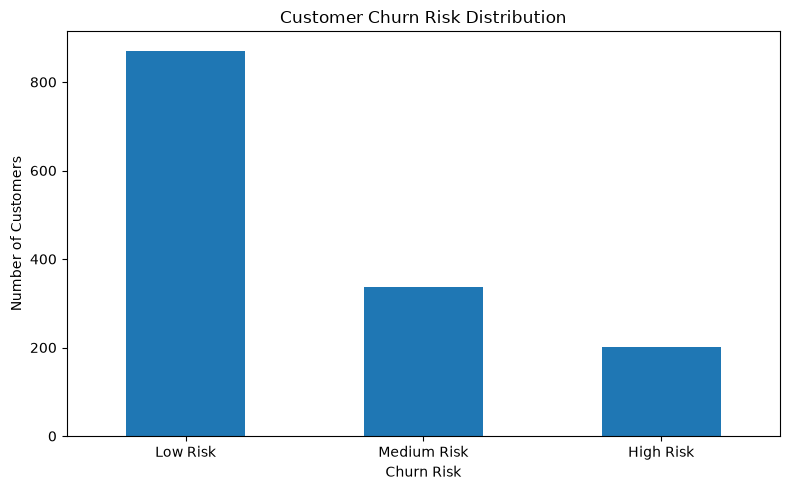

In [219]:
risk_counts = (
    ltv_df["Churn_Risk"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

plt.figure(figsize=(8, 5))

risk_counts.plot(kind="bar")

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Churn Risk")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

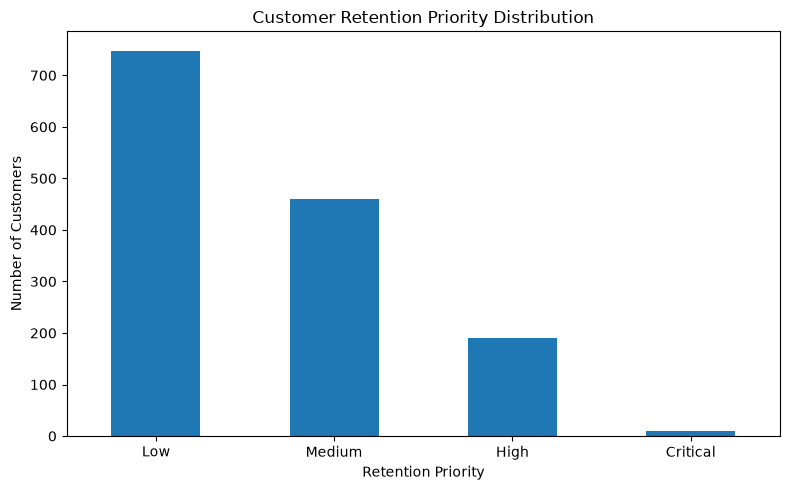

In [220]:
priority_counts = (
    ltv_df["Retention_Priority"]
    .value_counts()
    .reindex(["Low", "Medium", "High", "Critical"])
)

plt.figure(figsize=(8, 5))

priority_counts.plot(kind="bar")

plt.title("Customer Retention Priority Distribution")
plt.xlabel("Retention Priority")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

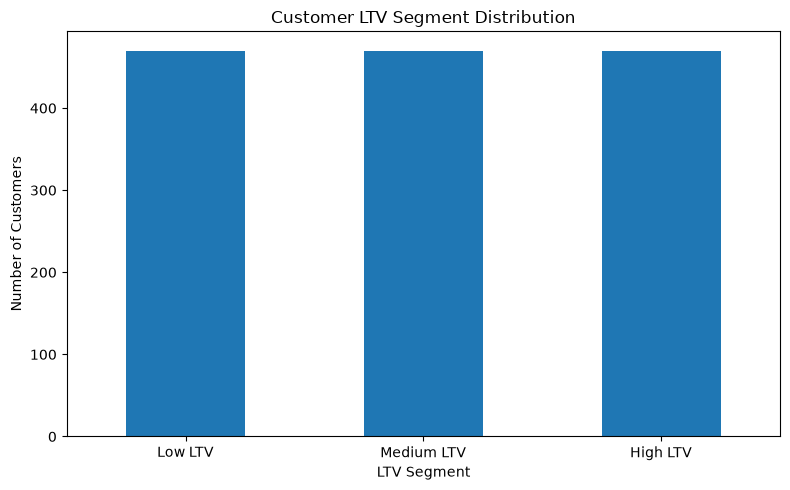

In [221]:
ltv_counts = (
    ltv_df["LTV_Segment"]
    .value_counts()
    .reindex(["Low LTV", "Medium LTV", "High LTV"])
)

plt.figure(figsize=(8, 5))

ltv_counts.plot(kind="bar")

plt.title("Customer LTV Segment Distribution")
plt.xlabel("LTV Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [222]:
risk_value_matrix = pd.crosstab(
    ltv_df["Churn_Risk"],
    ltv_df["Value_Segment"]
)

risk_value_matrix = risk_value_matrix.reindex(
    index=["Low Risk", "Medium Risk", "High Risk"],
    columns=["Low Value", "Medium Value", "High Value"],
    fill_value=0
)

risk_value_matrix

Value_Segment,Low Value,Medium Value,High Value
Churn_Risk,,,
Low Risk,193,315,363
Medium Risk,132,108,97
High Risk,145,46,10


<Figure size 800x500 with 0 Axes>

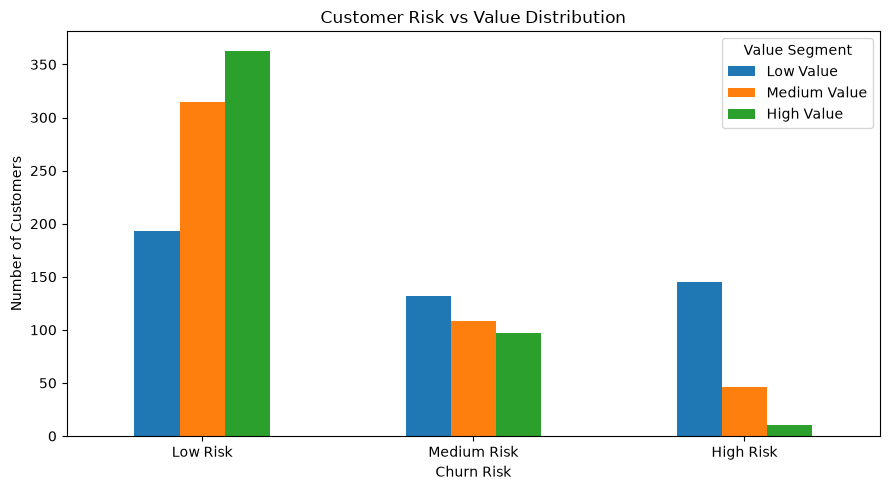

In [223]:
plt.figure(figsize=(8, 5))

risk_value_matrix.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Customer Risk vs Value Distribution")
plt.xlabel("Churn Risk")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Value Segment")
plt.tight_layout()
plt.show()

## Day 19 — Executive Dashboard Insights

The executive dashboard provides a consolidated view of customer churn risk, customer value, and retention priority.

Out of 1,409 analyzed customers, 201 customers were classified as High Risk. Within the retention-priority framework, 10 customers were classified as Critical and 191 as High priority.

The risk-value matrix provides an additional layer of business prioritization. The 10 High Risk–High Value customers represent the most important retention group because they combine elevated predicted churn risk with high customer value.

The dashboard therefore supports a differentiated retention strategy. Critical customers require immediate personalized attention, High-priority customers require targeted retention actions, Medium-priority customers require continued engagement, and Low-priority customers can be managed through regular communication and monitoring.

By combining churn probability, customer value, LTV segmentation, and retention priority, the dashboard converts individual machine learning predictions into a practical decision-support framework.

## Day 19 — Conclusion

The executive dashboard consolidates the project's major analytical outputs into a business-oriented decision-support view.

It combines predictive churn risk, customer value, predicted LTV, and retention priority to help identify where retention resources should be focused.

The dashboard demonstrates how machine learning predictions can be transformed into actionable customer segmentation and prioritization. This provides a clear bridge between technical model outputs and practical business decision-making.

# Day 20 — Final Model & Data Validation

The objective of this stage is to perform a final validation of the customer churn and LTV analysis pipeline.

The validation checks the structure and quality of the final customer-level dataset, including duplicate customer records, missing values, churn probability, predicted LTV, churn-risk classification, customer-value segmentation, retention priority, and recommended actions.

These checks help ensure that the outputs generated by the machine-learning and customer-value framework are internally consistent and suitable for the final business analysis and dashboard.

In [224]:
# ==========================================
# DAY 20 — FINAL DATA & MODEL VALIDATION
# ==========================================

print("=" * 60)
print("DAY 20 — FINAL PROJECT VALIDATION")
print("=" * 60)

print("\nDataset shape:", ltv_df.shape)

print("\nDuplicate CustomerIDs:")
print(ltv_df["customerID"].duplicated().sum())

print("\nMissing values:")
print(ltv_df.isnull().sum().sum())

print("\nChurn Probability range:")
print(
    round(ltv_df["Churn_Probability"].min(), 4),
    "to",
    round(ltv_df["Churn_Probability"].max(), 4)
)

print("\nPredicted LTV range:")
print(
    round(ltv_df["Predicted_LTV"].min(), 2),
    "to",
    round(ltv_df["Predicted_LTV"].max(), 2)
)

print("\nChurn Risk distribution:")
print(ltv_df["Churn_Risk"].value_counts())

print("\nValue Segment distribution:")
print(ltv_df["Value_Segment"].value_counts())

print("\nRetention Priority distribution:")
print(ltv_df["Retention_Priority"].value_counts())

print("\nRequired columns:")
required_columns = [
    "customerID",
    "Churn_Probability",
    "Customer_Value",
    "Predicted_LTV",
    "Churn_Risk",
    "Value_Segment",
    "Risk_Value_Segment",
    "Retention_Priority",
    "Recommended_Action"
]

for col in required_columns:
    print(f"{col}: {col in ltv_df.columns}")

DAY 20 — FINAL PROJECT VALIDATION

Dataset shape: (1409, 34)

Duplicate CustomerIDs:
0

Missing values:
0

Churn Probability range:
0.0028 to 0.9347

Predicted LTV range:
30.54 to 7008.0

Churn Risk distribution:
Churn_Risk
Low Risk       871
Medium Risk    337
High Risk      201
Name: count, dtype: int64

Value Segment distribution:
Value_Segment
Low Value       470
High Value      470
Medium Value    469
Name: count, dtype: int64

Retention Priority distribution:
Retention_Priority
Low         748
Medium      460
High        191
Critical     10
Name: count, dtype: int64

Required columns:
customerID: True
Churn_Probability: True
Customer_Value: True
Predicted_LTV: True
Churn_Risk: True
Value_Segment: True
Risk_Value_Segment: True
Retention_Priority: True
Recommended_Action: True


# Day 20 — Validation Conclusion

The final validation confirms that the customer churn and LTV analysis dataset contains 1,409 customer records with no duplicate CustomerIDs and no missing values.

The churn probability and predicted LTV values are within valid ranges, and the churn-risk distribution remains consistent with the previous analysis.

The required business-analysis fields, including churn risk, customer value segment, risk-value segment, retention priority, and recommended action, are also available in the final dataset.

These checks provide confidence that the analytical outputs are structurally consistent and ready for the final stages of project documentation, presentation, and delivery.

# Final Project Summary

The Customer Churn Prediction & LTV Engine combines customer churn prediction, customer lifetime value estimation, segmentation, and retention prioritization to support data-driven customer retention decisions.

The project evaluates multiple machine learning models for churn prediction and uses the best-performing model to generate churn probabilities. These predictions are combined with customer value and predicted LTV to identify different customer segments and retention priorities.

The final framework identifies customers who require different levels of retention attention, with the highest-risk and highest-value customers receiving the greatest priority.

The final validation confirms that the analytical dataset contains 1,409 customer records with no duplicate CustomerIDs and no missing values. The required analytical and business decision fields are also available in the final dataset.

Overall, the project demonstrates how machine learning and customer analytics can be transformed into practical business insights and targeted customer retention strategies.